### **MODELING**

In this section, we will focus on building and evaluating predictive models for Remaining Useful Life (RUL):

1. **Baseline Model:**

   * We will first implement a **Linear Regression model** as a baseline.
   * This will help us evaluate the impact of scaling and feature engineering on model performance.

2. **Advanced Models:**

   * After establishing the baseline, we will model the data using more advanced algorithms:

     * **XGBoost**
     * **NGBoost**
     * **Random Forest**
   * These models are chosen for their ability to capture non-linear relationships and complex feature interactions.

3. **Model Evaluation:**

   * The performance of each model will be assessed using regression metrics such as:

     * **Root Mean Squared Error (RMSE)**
     * **Mean Absolute Error (MAE)**
     * **R² Score**
   * This comparison will allow us to identify the best-performing model.

4. **Model Optimization:**

   * Once the best model is selected, we will perform **hyperparameter tuning** to further improve its predictive accuracy and generalization ability.

**The modeling phase will provide both a baseline and advanced approaches, enabling us to compare performance across different methods and identify the optimal model to predict RUL effectively.**




In [9]:
 # Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from ngboost import NGBRegressor
from ngboost.distns import Normal
from sklearn.metrics import  r2_score
from sklearn.metrics import mean_squared_error 
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score,KFold


In [3]:
 # Setting up the visualization style 
sns.set_style( style = 'darkgrid' )
sns.set_palette( palette = 'icefire' )

In [4]:
 # Loading the datasets 
cleaned_test_dfs = {}
cleaned_train_dfs = {}
train_dfs = {}
test_dfs = {}

names = ['FD001','FD002','FD003','FD004']
test_cleaned_csv = ['cleaned_test FD001 with RUL.csv','cleaned_test FD002 with RUL.csv','cleaned_test FD003 with RUL.csv','cleaned_test FD004 with RUL.csv']
train_cleaned_csv = ['cleaned_train FD001 with RUL.csv','cleaned_train FD002 with RUL.csv','cleaned_train FD003 with RUL.csv','cleaned_train FD004 with RUL.csv']

test_csv = ['test FD001 with RUL.csv','test FD002 with RUL.csv','test FD003 with RUL.csv','test FD004 with RUL.csv']
train_csv = ['train FD001 with RUL.csv','train FD002 with RUL.csv','train FD003 with RUL.csv','train FD004 with RUL.csv']

 # loading the datasets
for name , df1 , df2 , df3 , df4 in zip( names, test_cleaned_csv, train_cleaned_csv, test_csv, train_csv ):
    cleaned_test_dfs[name] = pd.read_csv(df1)
    cleaned_train_dfs[name] = pd.read_csv(df2)
    test_dfs[name] = pd.read_csv(df3)
    train_dfs[name] = pd.read_csv(df4)


we will first model the unscalled and unfeatured data to see how the model performs with unscalled data then compare the model performance with the scalled data.

In [4]:
 # pipeline
# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for (name1, df1) , (name2, df2)in zip(train_dfs.items(), test_dfs.items()):
    X_train = df1.iloc[ :,1:-1 ]
    y_train = df1.iloc[ :,-1 ]

    X_test = df2.iloc[ :,1:-1 ]
    y_test = df2.iloc[ :,-1 ]

     # --fitting a baseline model-- 
    reg1 = LinearRegression()
    reg1.fit(X_train, y_train )
    y_pred = reg1.predict( X_test )

    print(f'========= {name1} MODEL OUTPUTS ==========')
    print('R2 Score(Unscaled) :', r2_score( y_test, y_pred ))
    mse_baseline_unscalled = mean_squared_error(y_test, y_pred)
    print(f"MSE(Unscaled): {mse_baseline_unscalled}")

     # -- Cross Validation --
    cv_scores = cross_val_score(reg1, X_train, y_train, cv=cv, scoring='r2')
    print('Linear Regression (Unscaled) Cross validation R2 Mean :', cv_scores.mean())

     # --Ridge regression for regulization--
    ridge = Ridge(alpha= 1.0 )
    ridge.fit(X_train, y_train)
    y_pred_ridge = ridge.predict(X_test)
    
    print(f'Ridge Regression R2 Score(Unscaled) :', r2_score(y_test, y_pred_ridge))
    mse_ridge_unscalled = mean_squared_error(y_test, y_pred_ridge)
    print(f"MSE_ridge(Unscaled): {mse_ridge_unscalled}")
    
     # --Scalling the data--
    scaler = StandardScaler().set_output( transform = 'pandas')
    scaler.fit(X_train)

    scaled_X_train = scaler.transform(X_train)
    scaled_X_test = scaler.transform(X_test)
    
    reg2 = LinearRegression()
    reg2.fit(scaled_X_train,y_train)
    y_pred_scaled = reg2.predict(scaled_X_test)

    print('R2 Score(Scaled):', r2_score( y_test, y_pred_scaled ))
    mse_baseline_scaled = mean_squared_error(y_test, y_pred_scaled)
    print(f"MSE(Scaled): {mse_baseline_scaled}")
    
    # --Cross validation--
    cv_scores = cross_val_score(reg2, scaled_X_train, y_train, cv=cv, scoring='r2')
    print('Linear Regression (Scaled) Cross validation R2 Mean :', cv_scores.mean())
    
     # --Ridge regression for regulization--
    ridge = Ridge(alpha= 1.0 )
    ridge.fit(scaled_X_train, y_train)
    y_pred_ridge_scaled = ridge.predict(scaled_X_test)
    
    print(f'Ridge Regression (Scaled) R2 Score :', r2_score(y_test, y_pred_ridge_scaled))
    mse_ridge_scaled = mean_squared_error(y_test, y_pred_ridge_scaled)
    print(f"MSE_Rige(Scaled): {mse_ridge_scaled}")
    print('---'*50)


========= FD001 MODEL OUTPUTS ==========
R2 Score(Unscaled) : 0.6972198889255656
MSE(Unscaled): 522.8617692990639
Linear Regression (Unscaled) Cross validation R2 Mean : 0.7653736260953764
Ridge Regression R2 Score(Unscaled) : 0.6983297483170029
MSE_ridge(Unscaled): 520.9451868557164
R2 Score(Scaled): 0.6972198889255832
MSE(Scaled): 522.8617692990337
Linear Regression (Scaled) Cross validation R2 Mean : 0.76537362609538
Ridge Regression (Scaled) R2 Score : 0.6972239327641268
MSE_Rige(Scaled): 522.8547861171855
------------------------------------------------------------------------------------------------------------------------------------------------------
========= FD002 MODEL OUTPUTS ==========
R2 Score(Unscaled) : 0.6766257384518963
MSE(Unscaled): 935.2496850749297
Linear Regression (Unscaled) Cross validation R2 Mean : 0.7510060200153571
Ridge Regression R2 Score(Unscaled) : 0.6773250012838155
MSE_ridge(Unscaled): 933.2273059894515
R2 Score(Scaled): 0.6766257384518336
MSE(Scaled)

From the baseline experiments, **FD001** dataset is  the easiest dataset to model, achieving the **highest R² and lowest prediction error**, while **FD004** proves to be the most challenging due to its complex operating conditions and higher noise levels. **Ridge regression does not** consistently improve performance , while it provides a slight benefit in **FD003**, it  **reduces  the accuracy in FD004**, suggesting that regularization may sometimes remove informative variance. **Scaling  has no impact on model performance**. 

We will then model the datasets where we removed the low variance columns to see the effect on the models performance.


In [ ]:
 # pipeline
# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for (name1, df1) , (name2, df2)in zip(cleaned_train_dfs.items(), cleaned_test_dfs.items()):
    X_train = df1.iloc[ :,1:-1 ]
    y_train = df1.iloc[ :,-1 ]

    X_test = df2.iloc[ :,1:-1 ]
    y_test = df2.iloc[ :,-1 ]

     # --fitting a baseline model-- 
    reg3 = LinearRegression()
    reg3.fit(X_train, y_train )
    y_pred = reg3.predict( X_test )

    print(f'========= {name1} MODEL OUTPUTS ==========')
    print('R2 Score(Unscaled) :', r2_score( y_test, y_pred ))
    mse_baseline_unscalled = mean_squared_error(y_test, y_pred)
    print(f"MSE(Scaled): {mse_baseline_unscalled}")

     # -- Cross Validation --
    cv_scores = cross_val_score(reg3, X_train, y_train, cv=cv, scoring='r2')
    print('Linear Regression (Unscaled) Cross validation R2 Mean :', cv_scores.mean())


     # --Ridge regression for regulization--
    ridge = Ridge(alpha= 1.0 )
    ridge.fit(X_train, y_train)
    y_pred_ridge = ridge.predict(X_test)
    
    print(f'Ridge Regression R2 Score(Unscaled) :', r2_score(y_test, y_pred_ridge))
    mse_ridge_unscalled = mean_squared_error(y_test, y_pred_ridge)
    print(f"MSE_ridge(Unscaled): {mse_ridge_unscalled}")
    
     # --Scalling the data--
    scaler = StandardScaler().set_output( transform = 'pandas')
    scaler.fit(X_train)

    scaled_X_train = scaler.transform(X_train)
    scaled_X_test = scaler.transform(X_test)
    
    reg4 = LinearRegression()
    reg4.fit(scaled_X_train,y_train)
    y_pred_scaled = reg4.predict(scaled_X_test)

    print('R2 Score(Scaled):', r2_score( y_test, y_pred_scaled ))
    mse_baseline_scaled = mean_squared_error(y_test, y_pred_scaled)
    print(f"MSE(Scaled): {mse_baseline_scaled}")
    
    # --Cross validation--
    cv_scores = cross_val_score(reg4, scaled_X_train, y_train, cv=cv, scoring='r2')
    print('Linear Regression (Scaled) Cross validation R2 Mean :', cv_scores.mean())
    
     # --Ridge regression for regulization--
    ridge = Ridge(alpha= 1.0 )
    ridge.fit(scaled_X_train, y_train)
    y_pred_ridge_scaled = ridge.predict(scaled_X_test)
    
    print(f'Ridge Regression (Scaled) R2 Score :', r2_score(y_test, y_pred_ridge_scaled))
    mse_ridge_scaled = mean_squared_error(y_test, y_pred_ridge_scaled)
    print(f"MSE_Rige(Scaled): {mse_ridge_scaled}")
    print('---'*50)


========= FD001 MODEL OUTPUTS ==========
R2 Score(Unscaled) : 0.6970361032923211
MSE(Scaled): 523.1791431220305
Linear Regression (Unscaled) Cross validation R2 Mean : 0.7631424734552641
Ridge Regression R2 Score(Unscaled) : 0.6969431081554582
MSE_ridge(Unscaled): 523.339733596827
R2 Score(Scaled): 0.6970361032923144
MSE(Scaled): 523.1791431220423
Linear Regression (Scaled) Cross validation R2 Mean : 0.763142473455264
Ridge Regression (Scaled) R2 Score : 0.6970400859415126
MSE_Rige(Scaled): 523.1722656062145
------------------------------------------------------------------------------------------------------------------------------------------------------
========= FD002 MODEL OUTPUTS ==========
R2 Score(Unscaled) : 0.6777829618269525
MSE(Scaled): 931.9028114186859
Linear Regression (Unscaled) Cross validation R2 Mean : 0.7506118061709335
Ridge Regression R2 Score(Unscaled) : 0.6774339114568133
MSE_ridge(Unscaled): 932.9123204846987
R2 Score(Scaled): 0.6777829618270872
MSE(Scaled): 93

After re-modelling using datasets where **low-variance columns were removed** The  results show that removing low variance columns **has almost no effect on model performance across most datasets**, with R² and MSE values remaining largely unchanged. This shows that such features were either redundant but may carry minimal predictive value except  in **FD003** where  removing these columns reduced performance,**showing that even low variance features can carry relevant signals**. Comparing linear and ridge regression further confirms that **regularization does not  improve results**. 
**FD002 shows a marginal gain when scaled ridge regression is applied (R² increasing from 0.678 to 0.679 and MSE dropping from ~932 to ~929).** 
In **FD004 ridge regression actually decreases predictive accuracy**, confirming its limited utility in this context.

linear regression remains the most stable baseline model across the datasets. Performance differences between cross-validation and test sets also show a persistent generalization gap, highlighting that test sets are harder to predict . 

#### **CONCLUSIONS**
The findings confirm that linear models, even with regularization and feature selection, are insufficient for capturing the complex and nonlinear degradation dynamics in engine data. Moving forward, non-linear methods such as random forests, gradient boosting, or neural networks are better candidates for improving predictive accuracy. 



******FD001 MODEL PEFORMANCE******
Mean Squared Error (MSE): 353.28
R² Score: 0.80


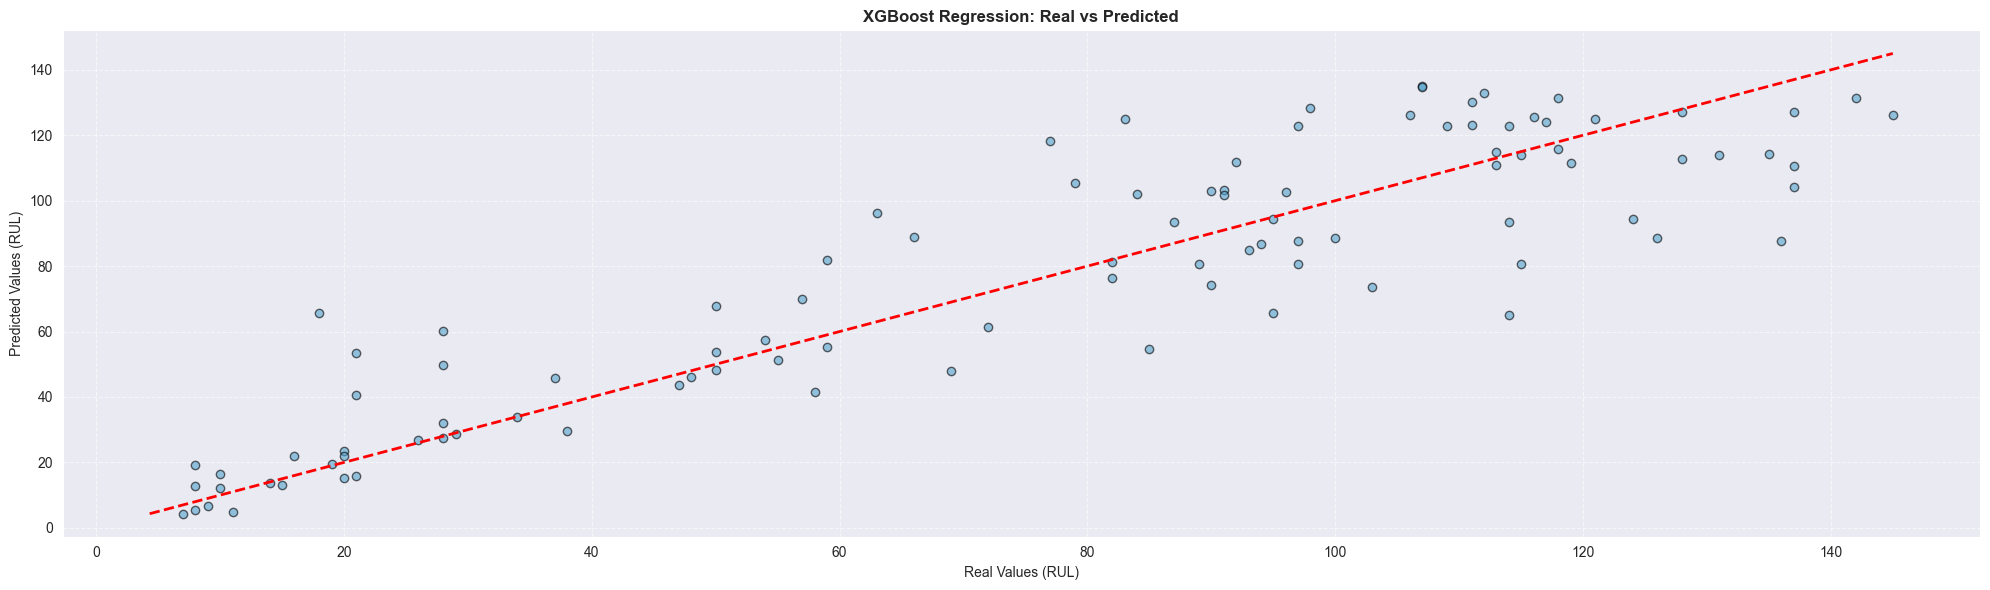

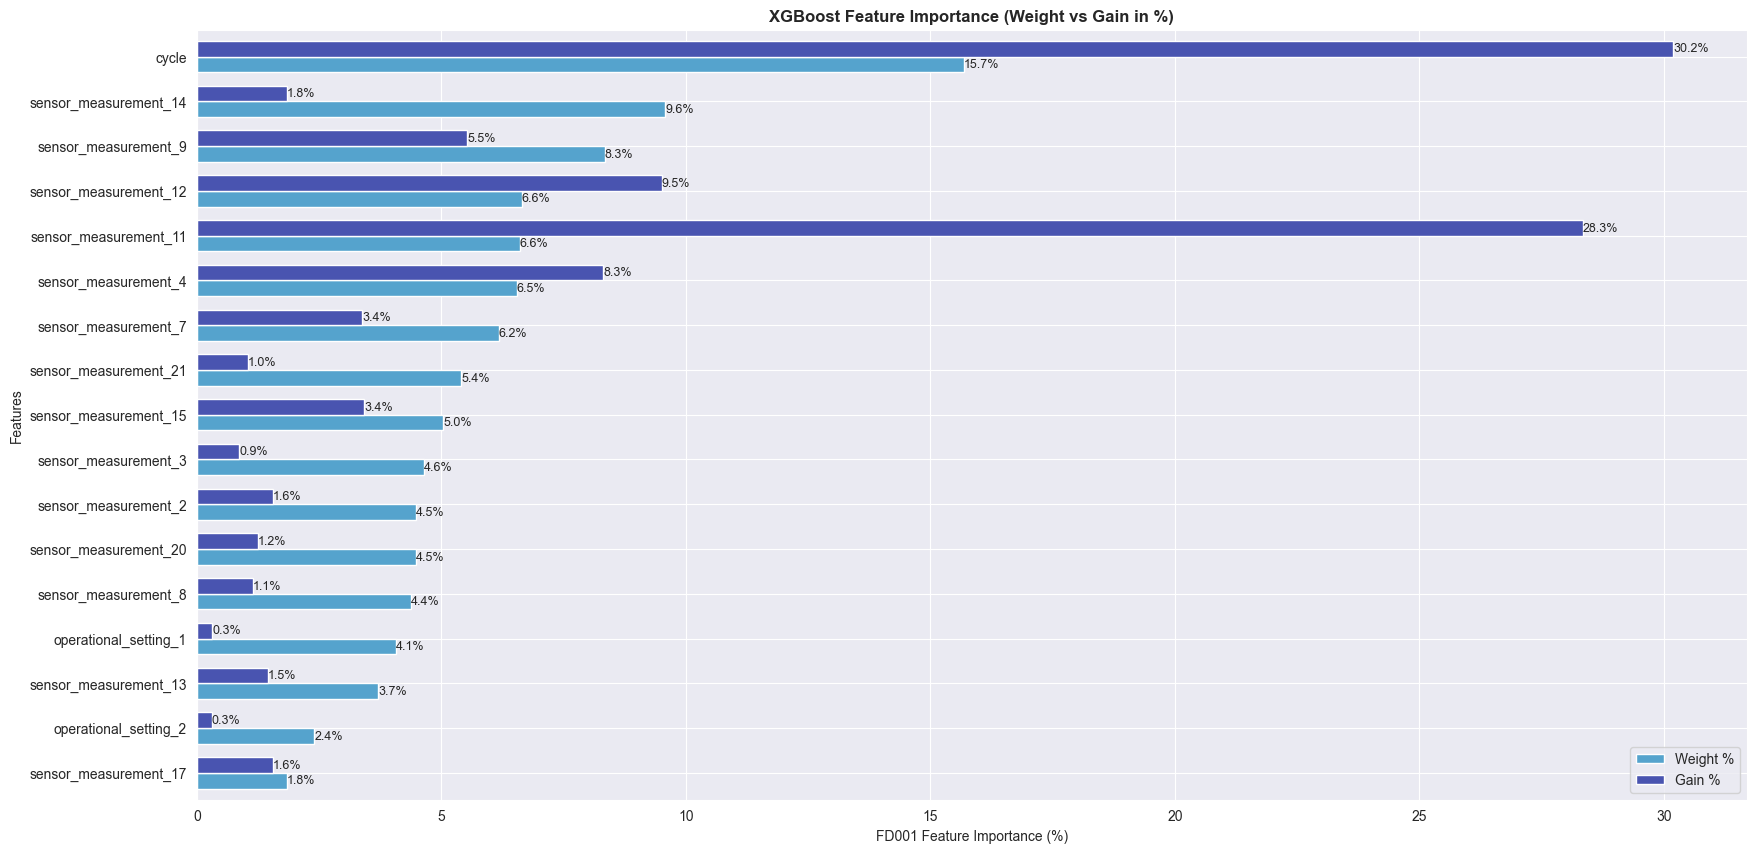

******FD002 MODEL PEFORMANCE******
Mean Squared Error (MSE): 733.84
R² Score: 0.75


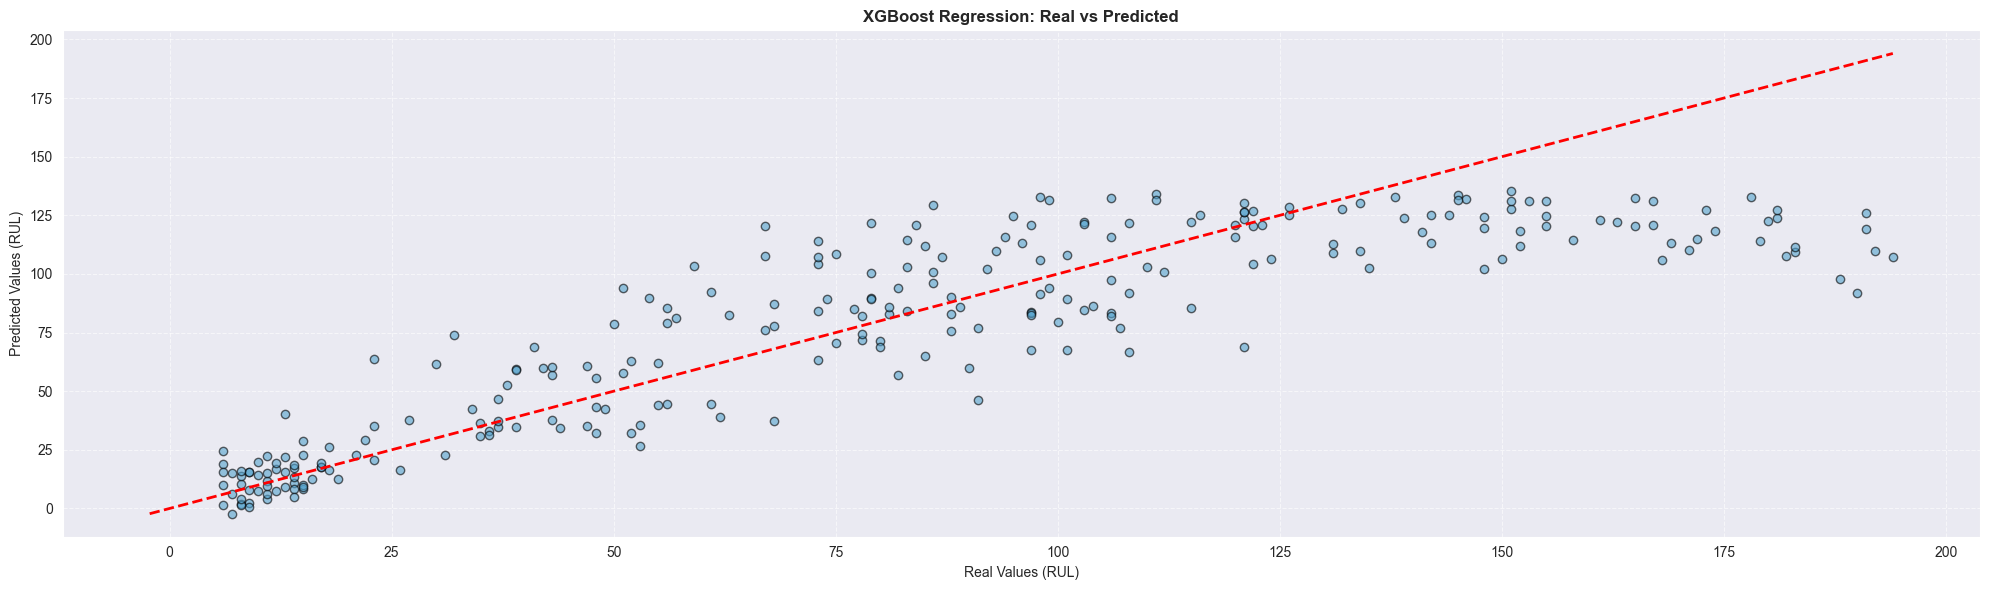

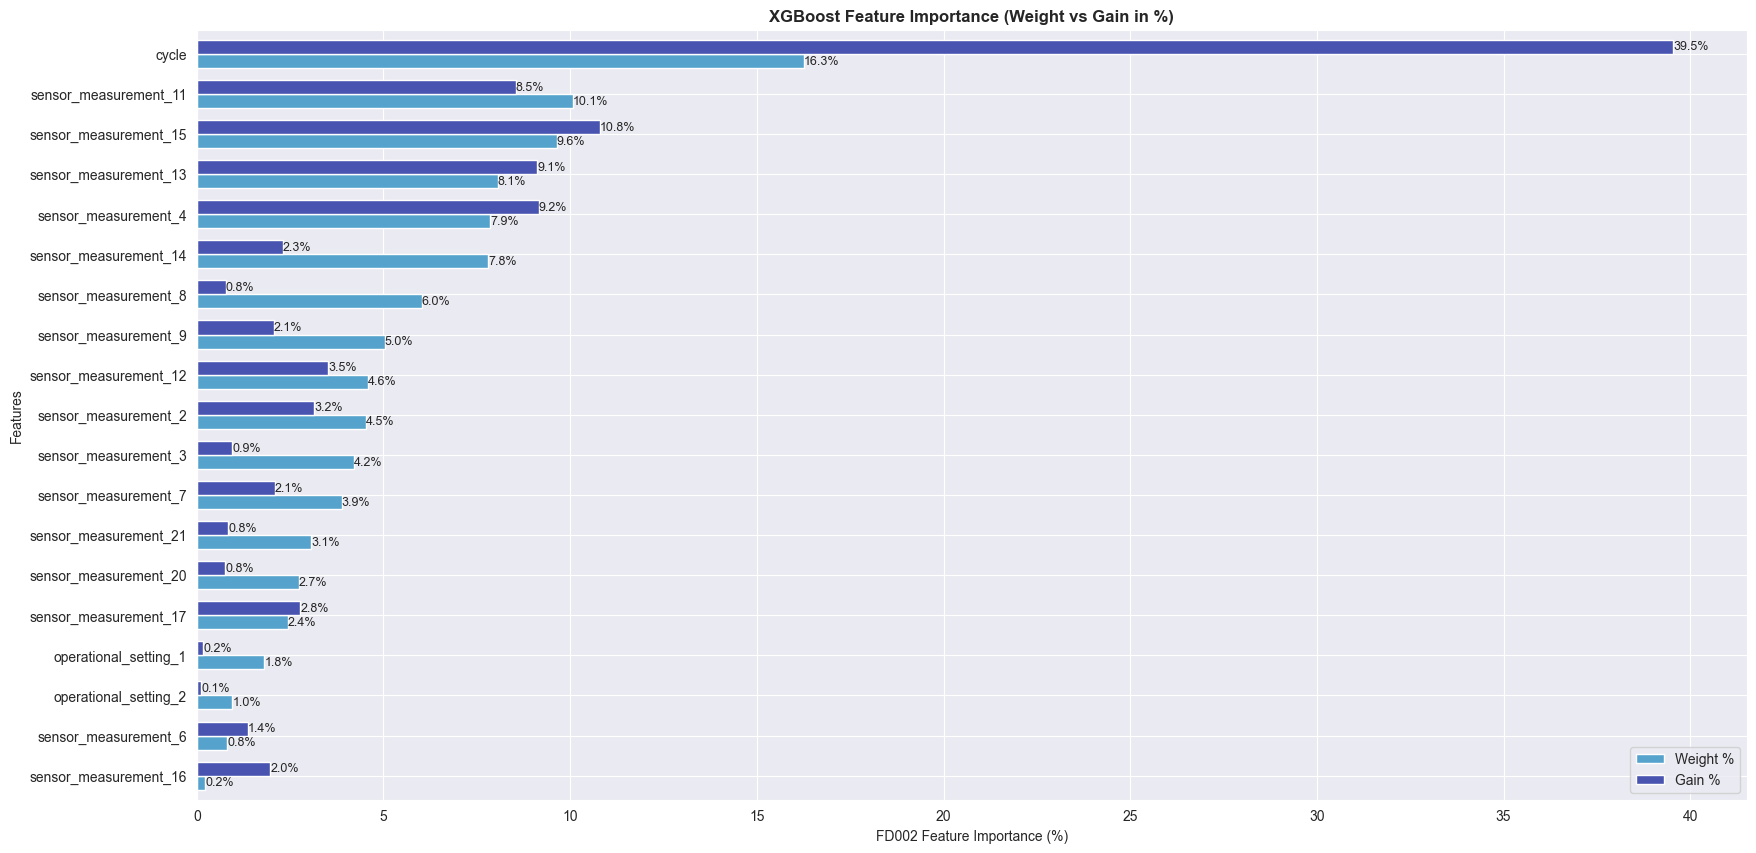

******FD003 MODEL PEFORMANCE******
Mean Squared Error (MSE): 361.84
R² Score: 0.79


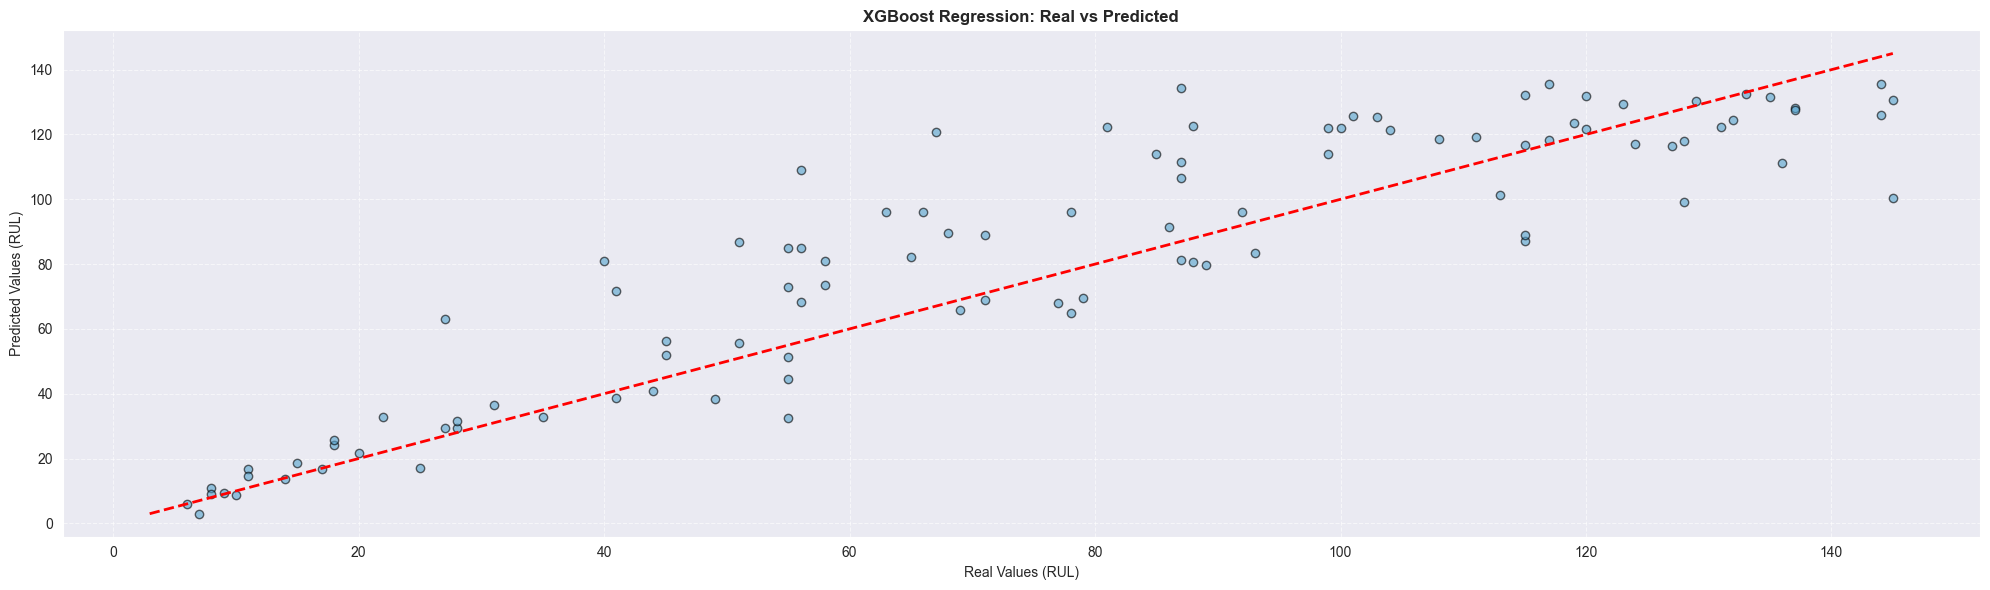

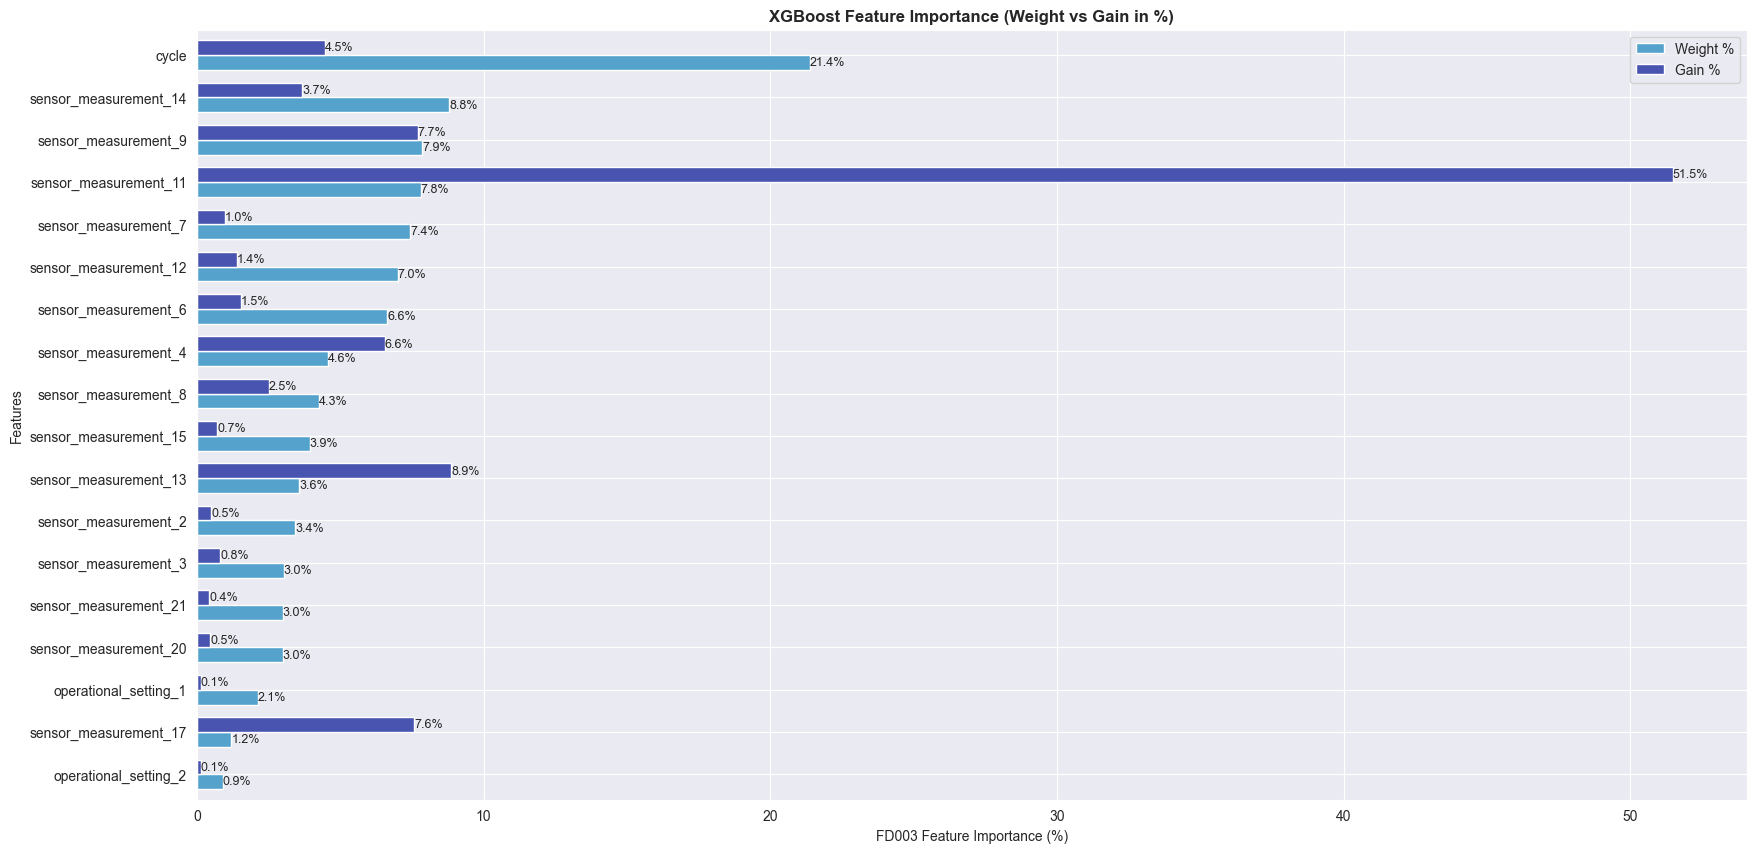

******FD004 MODEL PEFORMANCE******
Mean Squared Error (MSE): 766.16
R² Score: 0.74


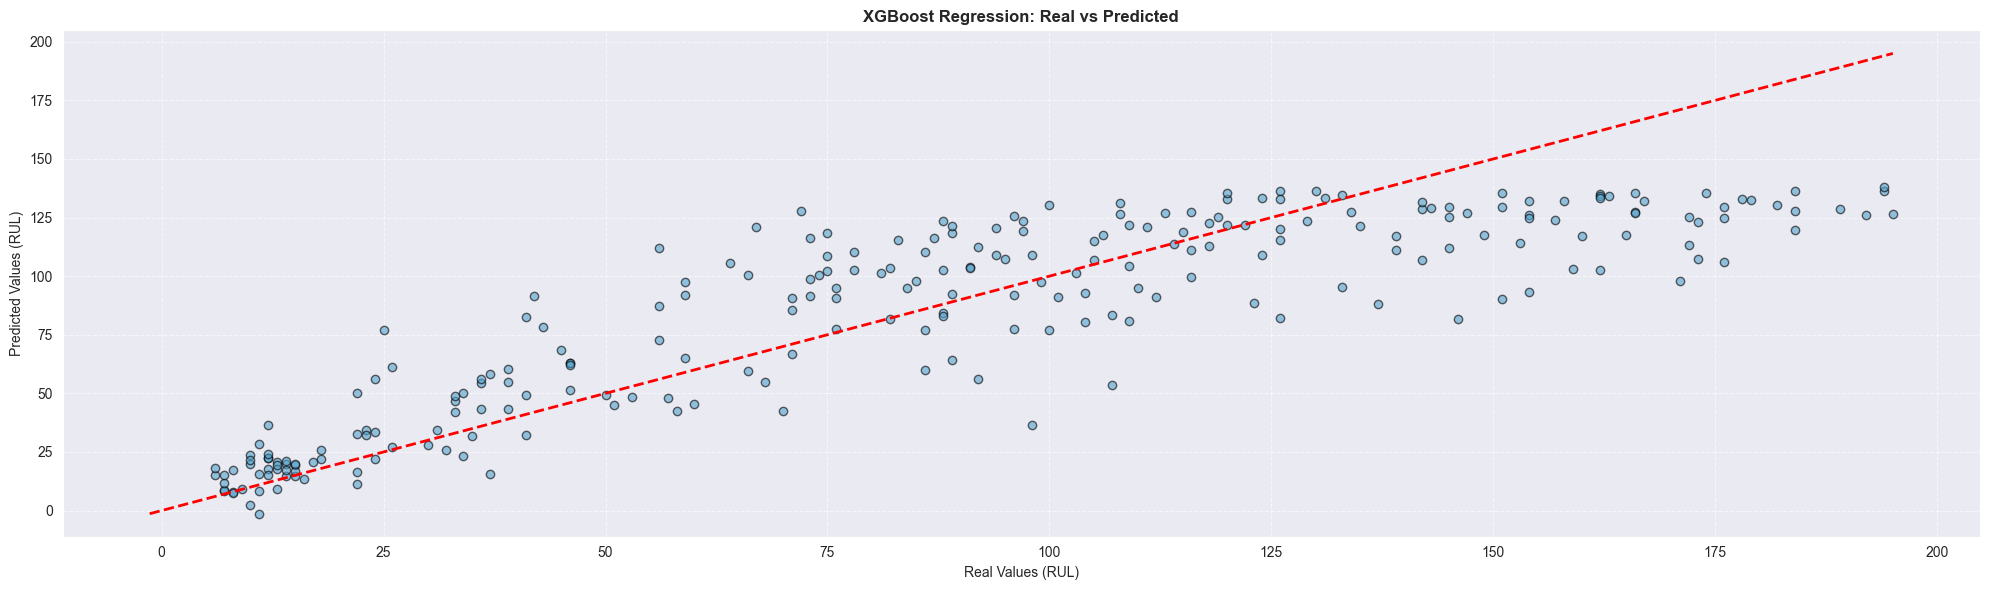

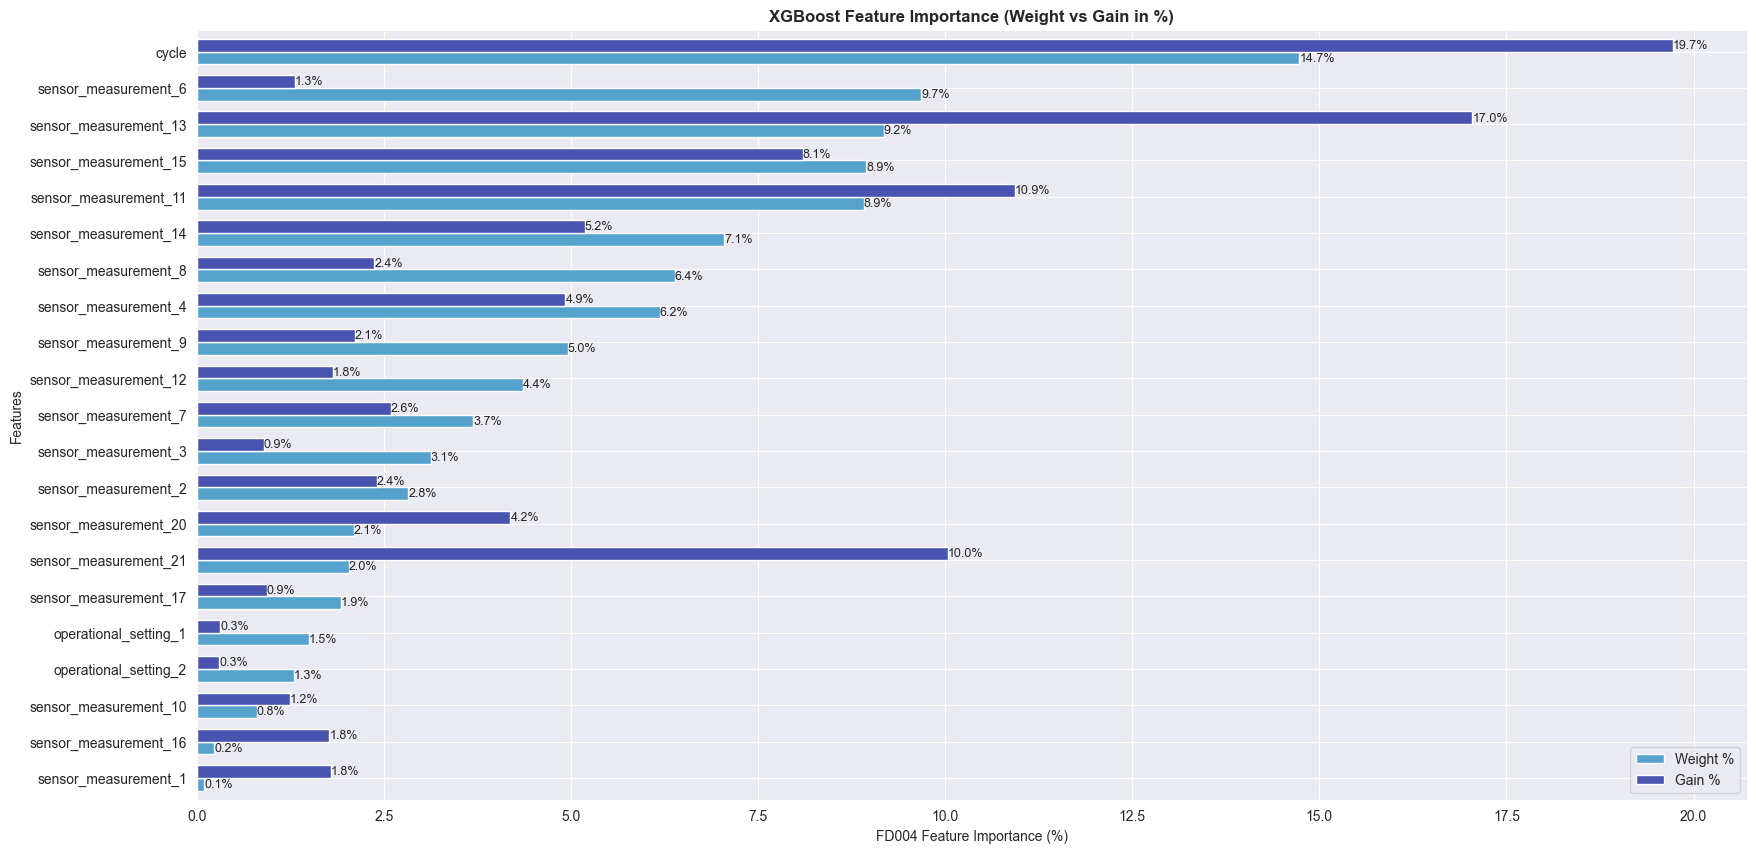

***** MEAN PERFORMANCE *****
R2 MEAN:  0.7682020962238312
MSE MEAN:  553.7803115844727


In [7]:
 # Modelling using XG boost
r2_list_xgboost = []
mse_list_xgboost = []

for (name1, df1) , (name2, df2)in zip(train_dfs.items(), test_dfs.items()):
    X_train = df1.iloc[ :,1:-1 ]
    y_train = df1.iloc[ :,-1 ]

    X_test = df2.iloc[ :,1:-1 ]
    y_test = df2.iloc[ :,-1 ]
    

    model = XGBRegressor(
        n_estimators=100,      
        learning_rate=0.1,     
        max_depth=5,           
        subsample=0.8,         
        colsample_bytree=0.8,  
        random_state=42
    )
     # Fitting the model
    model.fit(X_train, y_train)

    # Preddicting 
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    r2_list_xgboost.append(r2)
    mse_list_xgboost.append(mse)

    print(f'******{name1} MODEL PEFORMANCE******')
    print(f'Mean Squared Error (MSE): {mse:.2f}')
    print(f'R² Score: {r2:.2f}')
    
     # Plotting the scatter plot 
    plt.figure(figsize=(20,6))
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')

    # 45-degree line (perfect prediction)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

    plt.title('XGBoost Regression: Real vs Predicted', fontweight = 'bold')
    plt.xlabel('Real Values (RUL)')
    plt.ylabel('Predicted Values (RUL)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Getting the important features.
    booster = model.get_booster()
    weight_dict = booster.get_score(importance_type='weight')
    gain_dict   = booster.get_score(importance_type='gain')

    # Changing to dataframes 
    df_weight = pd.DataFrame.from_dict(weight_dict, orient='index', columns=['weight'])
    df_gain   = pd.DataFrame.from_dict(gain_dict, orient='index', columns=['gain'])

    df_weight['weight'] = 100 * df_weight['weight'] / df_weight['weight'].sum()
    df_gain['gain']     = 100 * df_gain['gain'] / df_gain['gain'].sum()

    # Merge into one DataFrame
    importance_df = df_weight.join(df_gain)
    importance_df = importance_df.sort_values(by='weight', ascending=True)

    # Plot 
    ax = importance_df.plot(
        kind='barh',
        figsize=(20, 10),
        width=0.7
    )

    # Add labels to each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)

    plt.xlabel(f'{name1} Feature Importance (%)')
    plt.ylabel('Features')
    plt.title('XGBoost Feature Importance (Weight vs Gain in %)', fontweight = 'bold')
    plt.legend(['Weight %', "Gain %"])
    plt.show()

print('***** MEAN PERFORMANCE *****')
print('R2 MEAN: ', np.mean(r2_list_xgboost))
print('MSE MEAN: ', np.mean(mse_list_xgboost))

From the modeling outputs using **XGBoost**, we observe notable improvements compared to linear regression across all datasets. For **FD001**, the model achieves an MSE of **353.81** with an **R² of 0.80**. The scatter plot reveals an upward diagonal trend, with points clustering around the diagonal at lower RUL values but spreading out at higher RUL. In particular, the model both overpredicts and underpredicts at higher RUL values, suggesting difficulty in extrapolating long lifespans. The most important predictive features are the **cycle** variable along with sensor measurements **14, 9, 12, and 11**.

For **FD002**, performance is lower, with an MSE of **733.81** and an **R² of 0.75**. The scatter plot again shows an upward trend: predictions align closely with the diagonal at lower RUL, but diverge substantially at higher RUL, where most points lie below the diagonal. This indicates systematic underprediction in the high-RUL range, consistent with FD001 but with a wider spread. The most influential features are **cycle** and sensor measurements **11, 15, 13, and 4**.

For **FD003**, the model yields an MSE of **361.84** and an **R² of 0.79**. The scatter plot demonstrates good alignment with the diagonal at lower RUL, but beyond RUL \~40, many predictions lie above the diagonal, indicating a tendency to overpredict at higher RUL values. Key predictors include **cycle** and sensor measurements **14, 9, 11, and 7**.

Finally, for **FD004**, XGBoost achieves an MSE of **766.16** and an **R² of 0.74**. The scatter plot resembles that of FD002, with predictions tracking the diagonal at lower RUL but diverging below it at higher RUL, again showing underprediction of long lifespans. The most important predictors are **cycle** and sensor measurements **6, 13, 15, and 11**.

Overall, the results demonstrate that **XGBoost outperforms linear regression**, achieving higher R² and lower MSE values across all datasets. The model is effective at capturing overall RUL trends but still struggles with extreme values, particularly in extrapolating to higher RUL ranges. Importantly, feature importance analysis highlights that **cycle** and **sensor measurement 11** consistently emerge as critical predictors of engine degradation across datasets.

Aggregating performance across all four datasets, the mean R² score for XGBoost is 0.76, while the mean MSE is 553.78. This confirms that XGBoost consistently outperforms the linear baseline, offering a stronger balance between bias and variance across different operating conditions.

We next extend our modeling by applying NGBoost (Natural Gradient Boosting) to the datasets. This approach allows us to compare its performance against both XGBoost and the baseline linear regression models.

[iter 0] loss=5.2292 val_loss=0.0000 scale=1.0000 norm=40.1498
******FD001 MODEL PEFORMANCE******
Mean Squared Error (MSE): 384.98
R² Score: 0.78


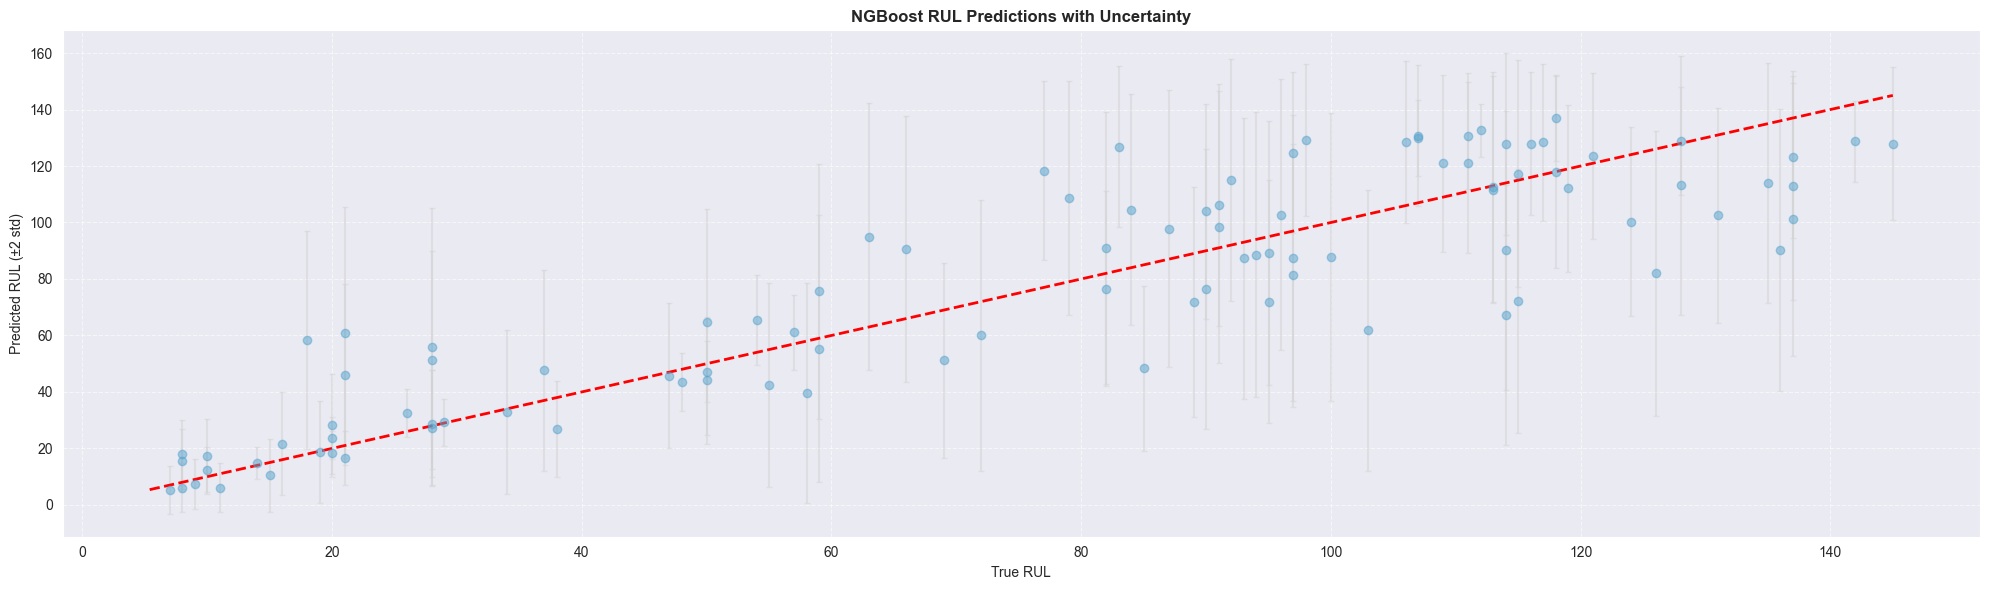

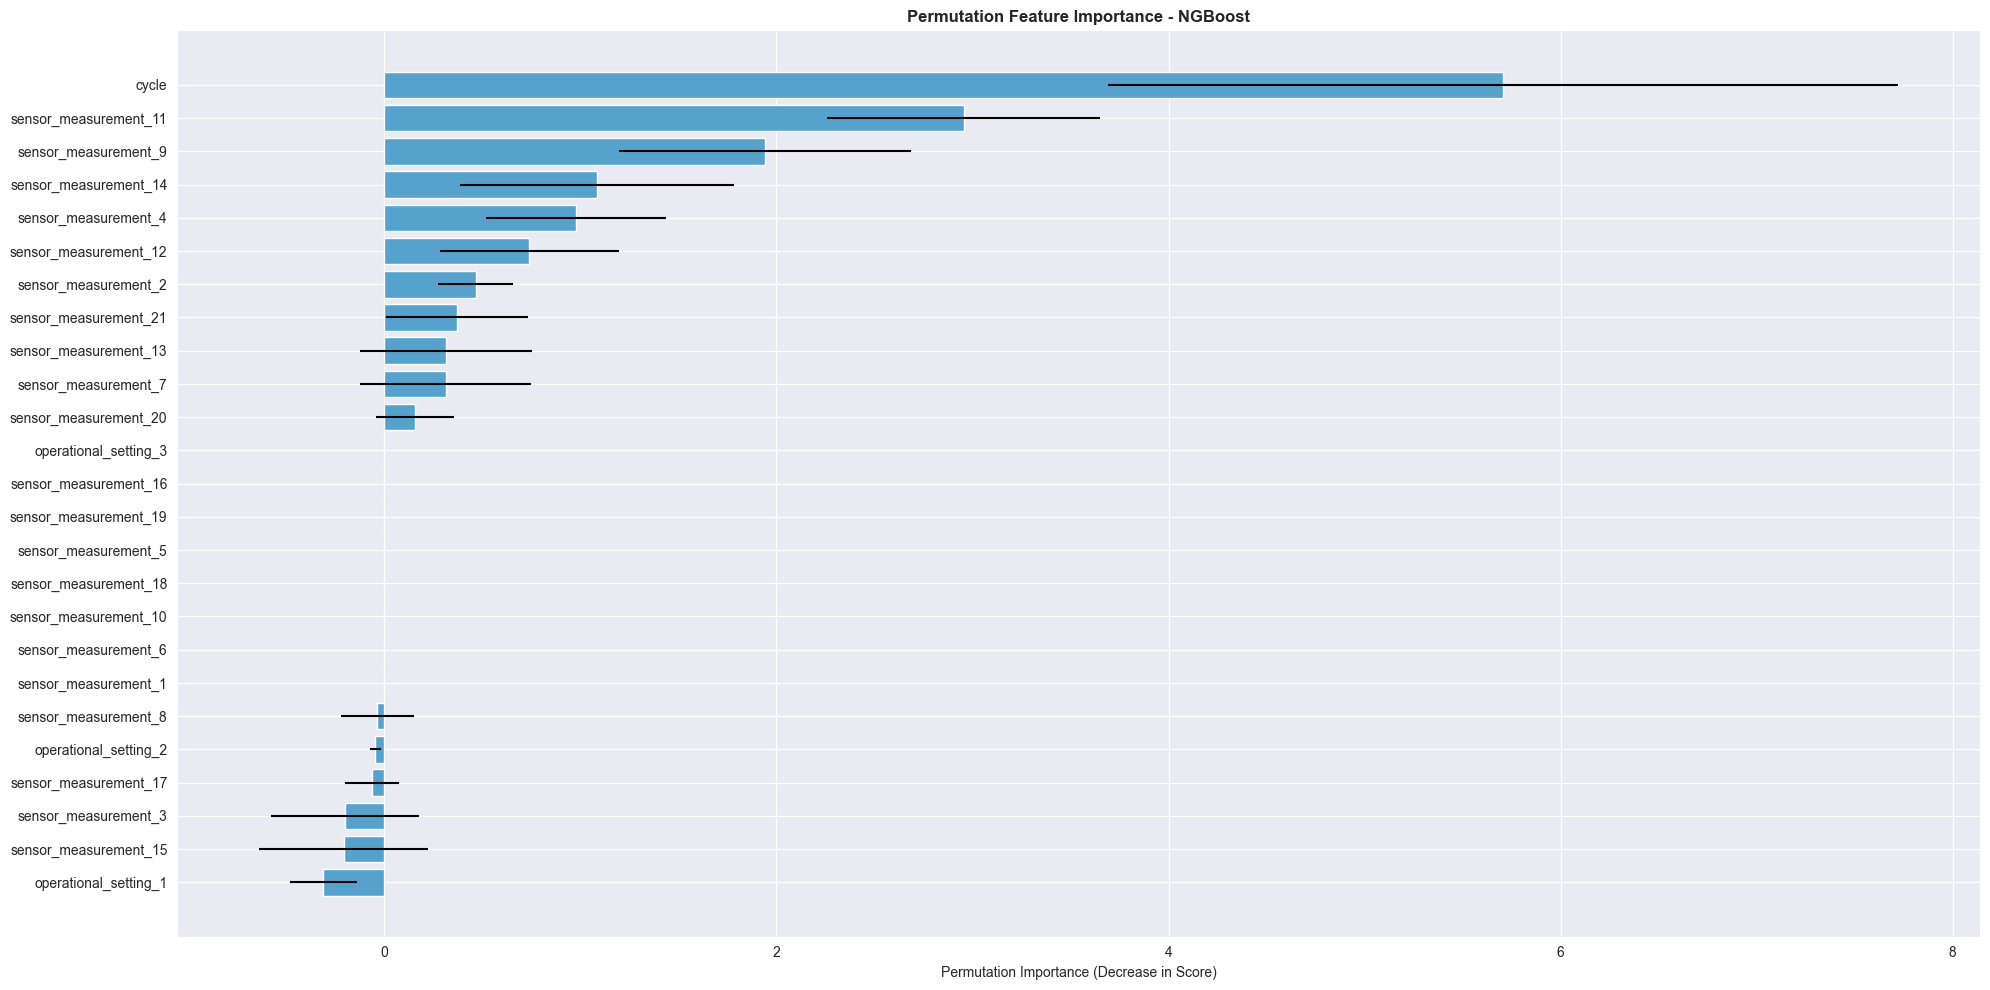

[iter 0] loss=5.2292 val_loss=0.0000 scale=1.0000 norm=40.1473
******FD002 MODEL PEFORMANCE******
Mean Squared Error (MSE): 723.22
R² Score: 0.75


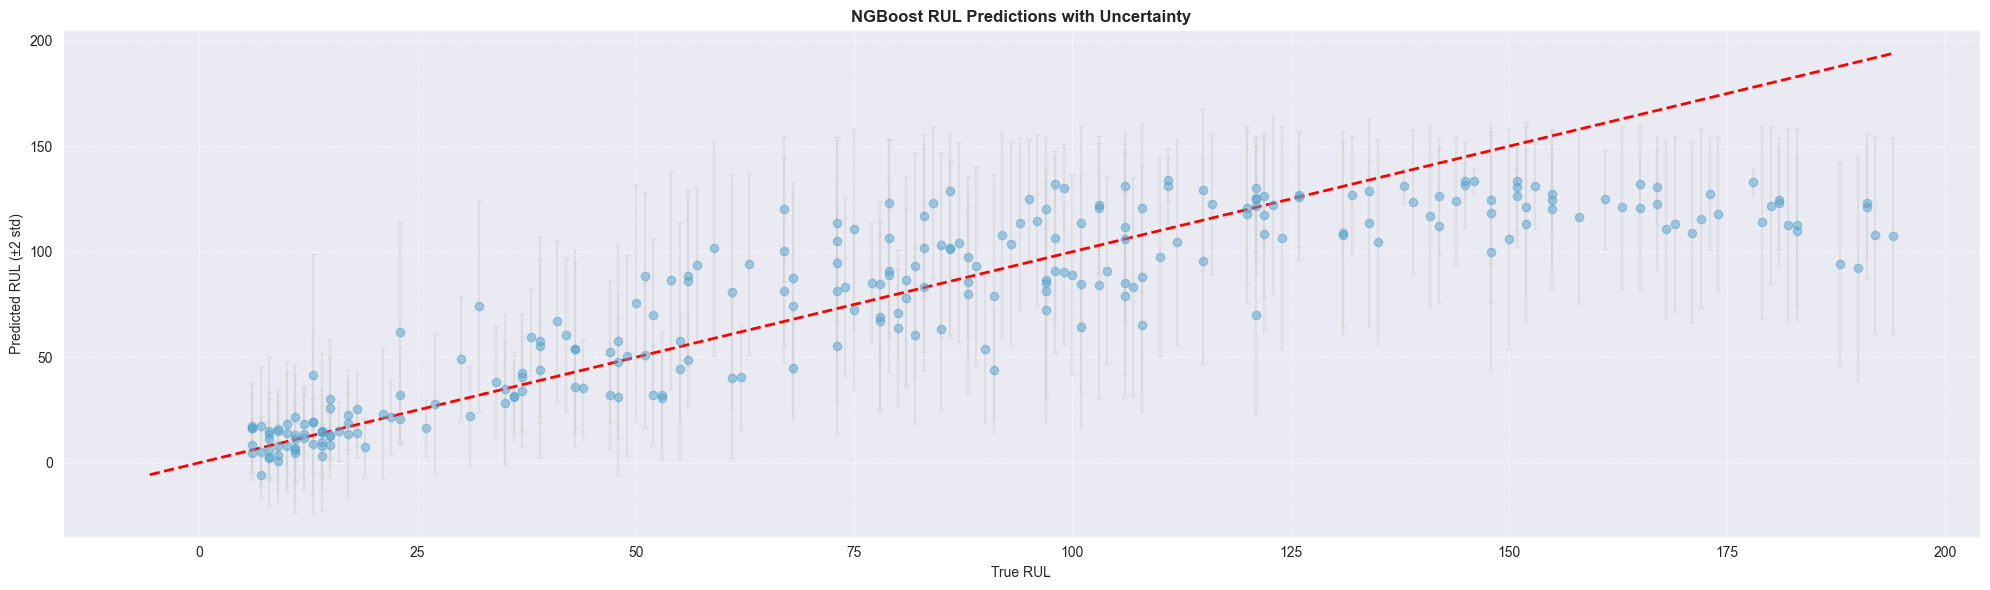

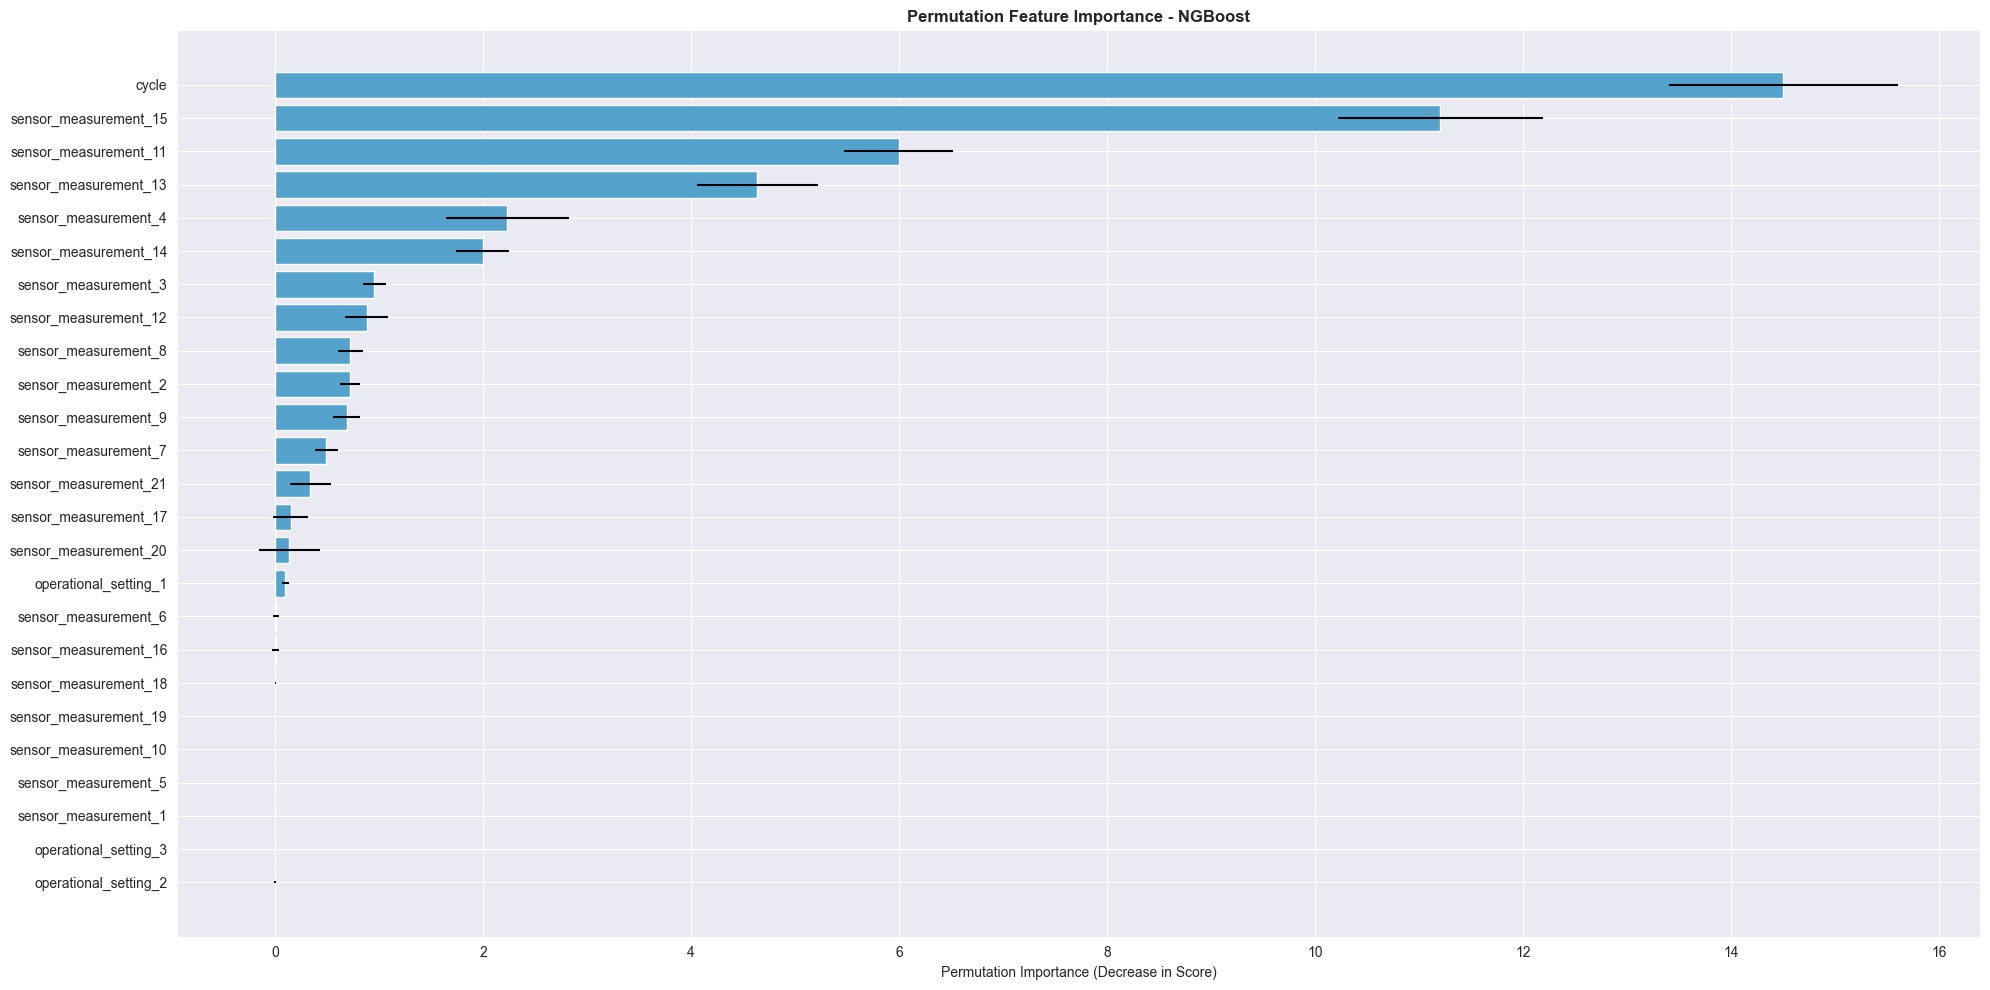

[iter 0] loss=5.2132 val_loss=0.0000 scale=1.0000 norm=39.1464
******FD003 MODEL PEFORMANCE******
Mean Squared Error (MSE): 352.57
R² Score: 0.79


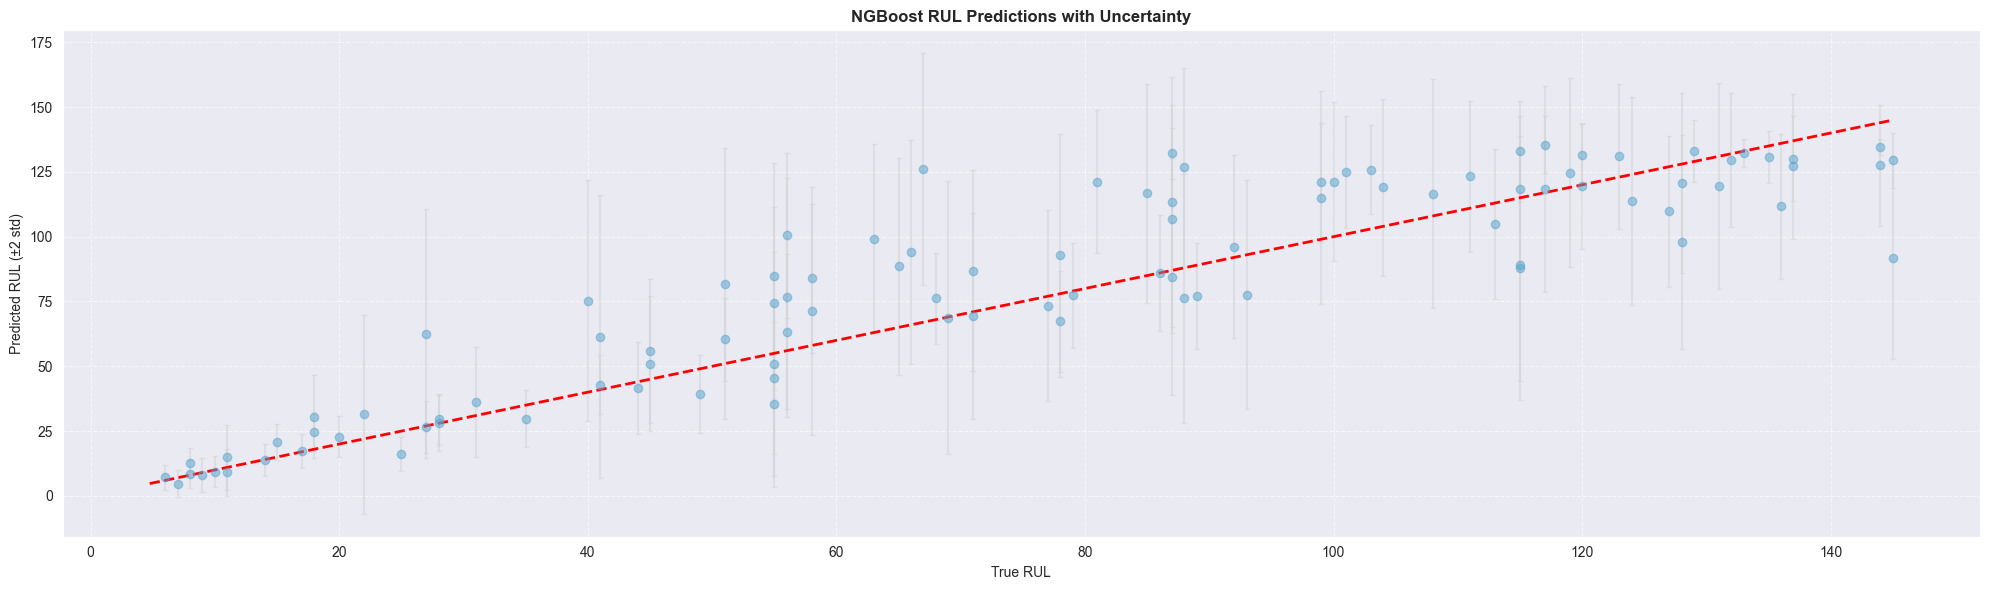

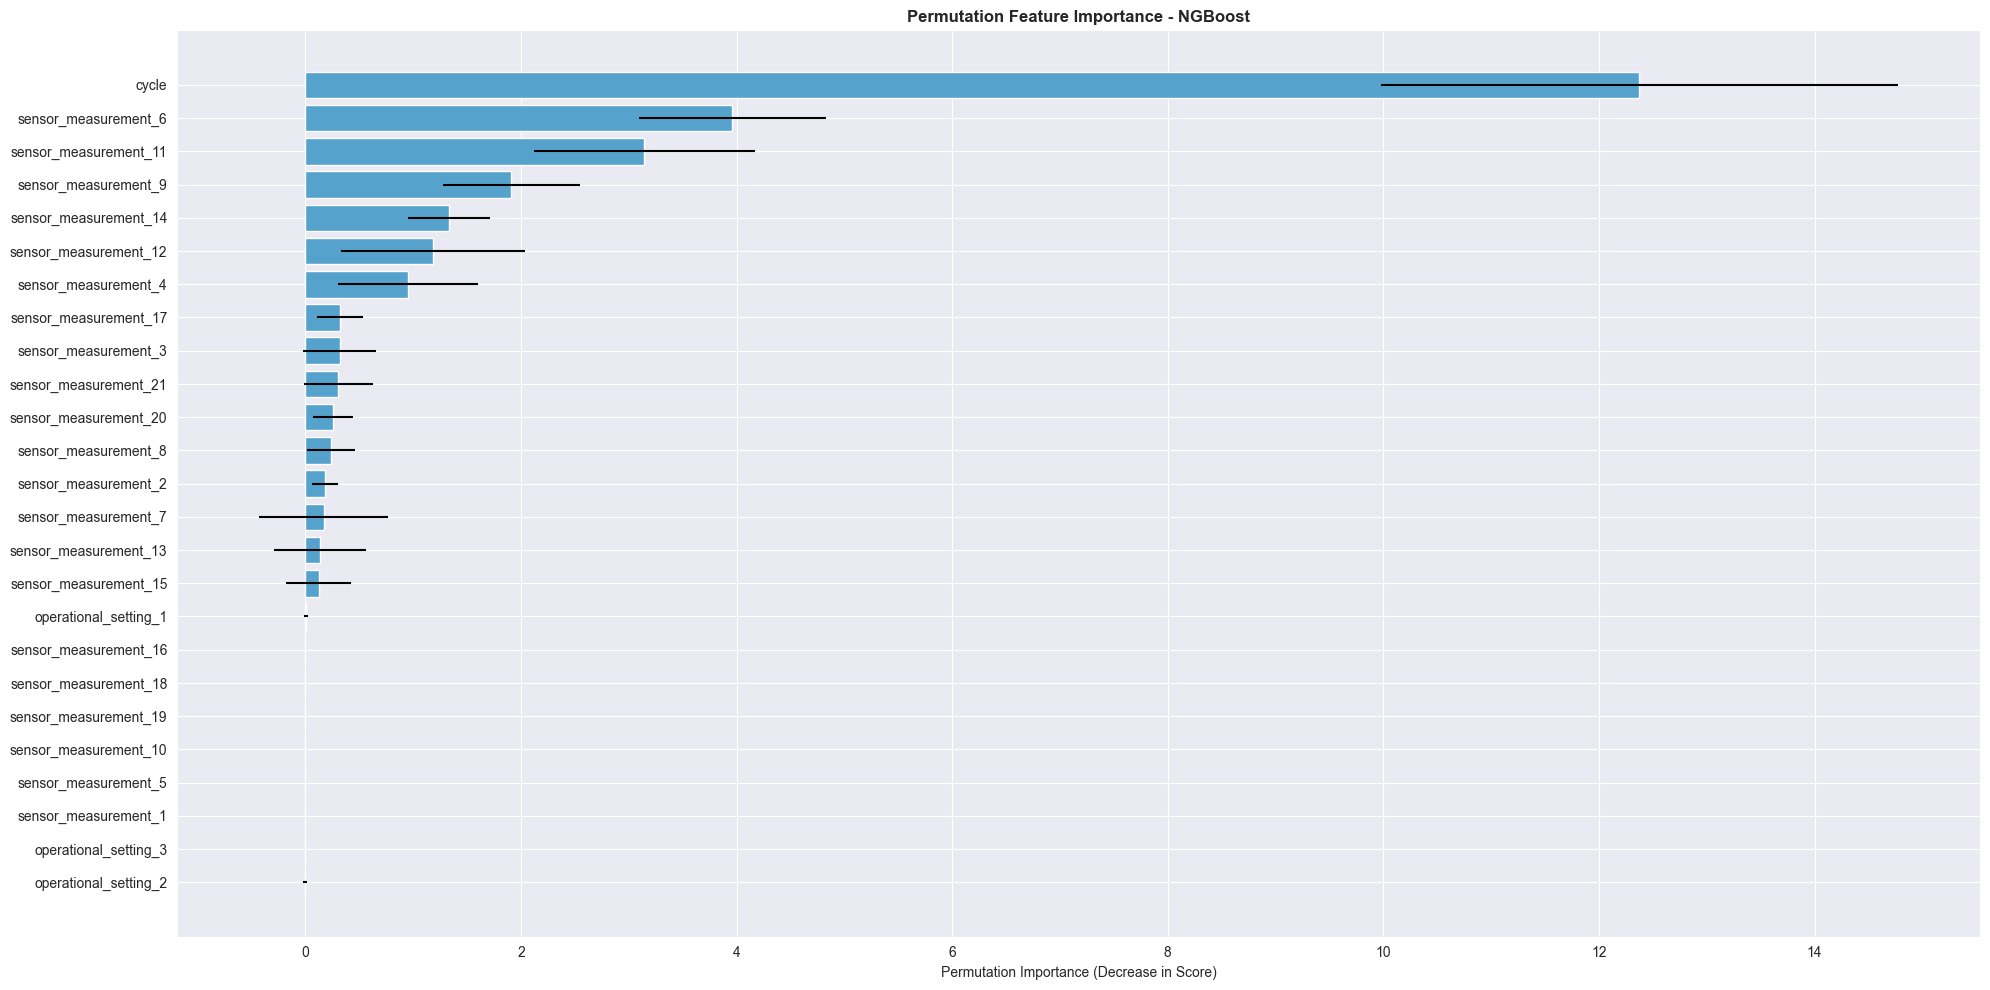

[iter 0] loss=5.2140 val_loss=0.0000 scale=1.0000 norm=39.1940
******FD004 MODEL PEFORMANCE******
Mean Squared Error (MSE): 766.34
R² Score: 0.74


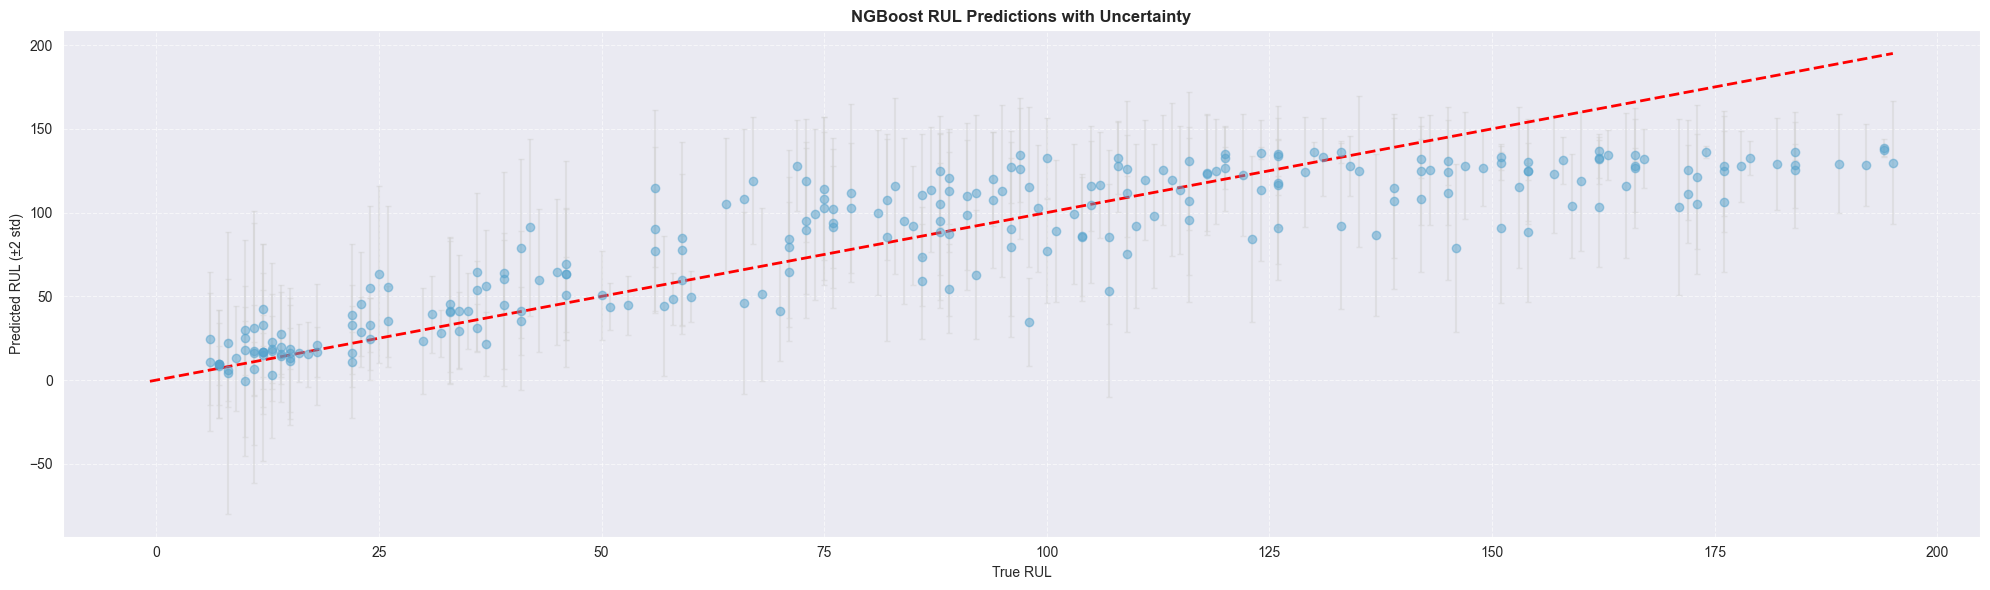

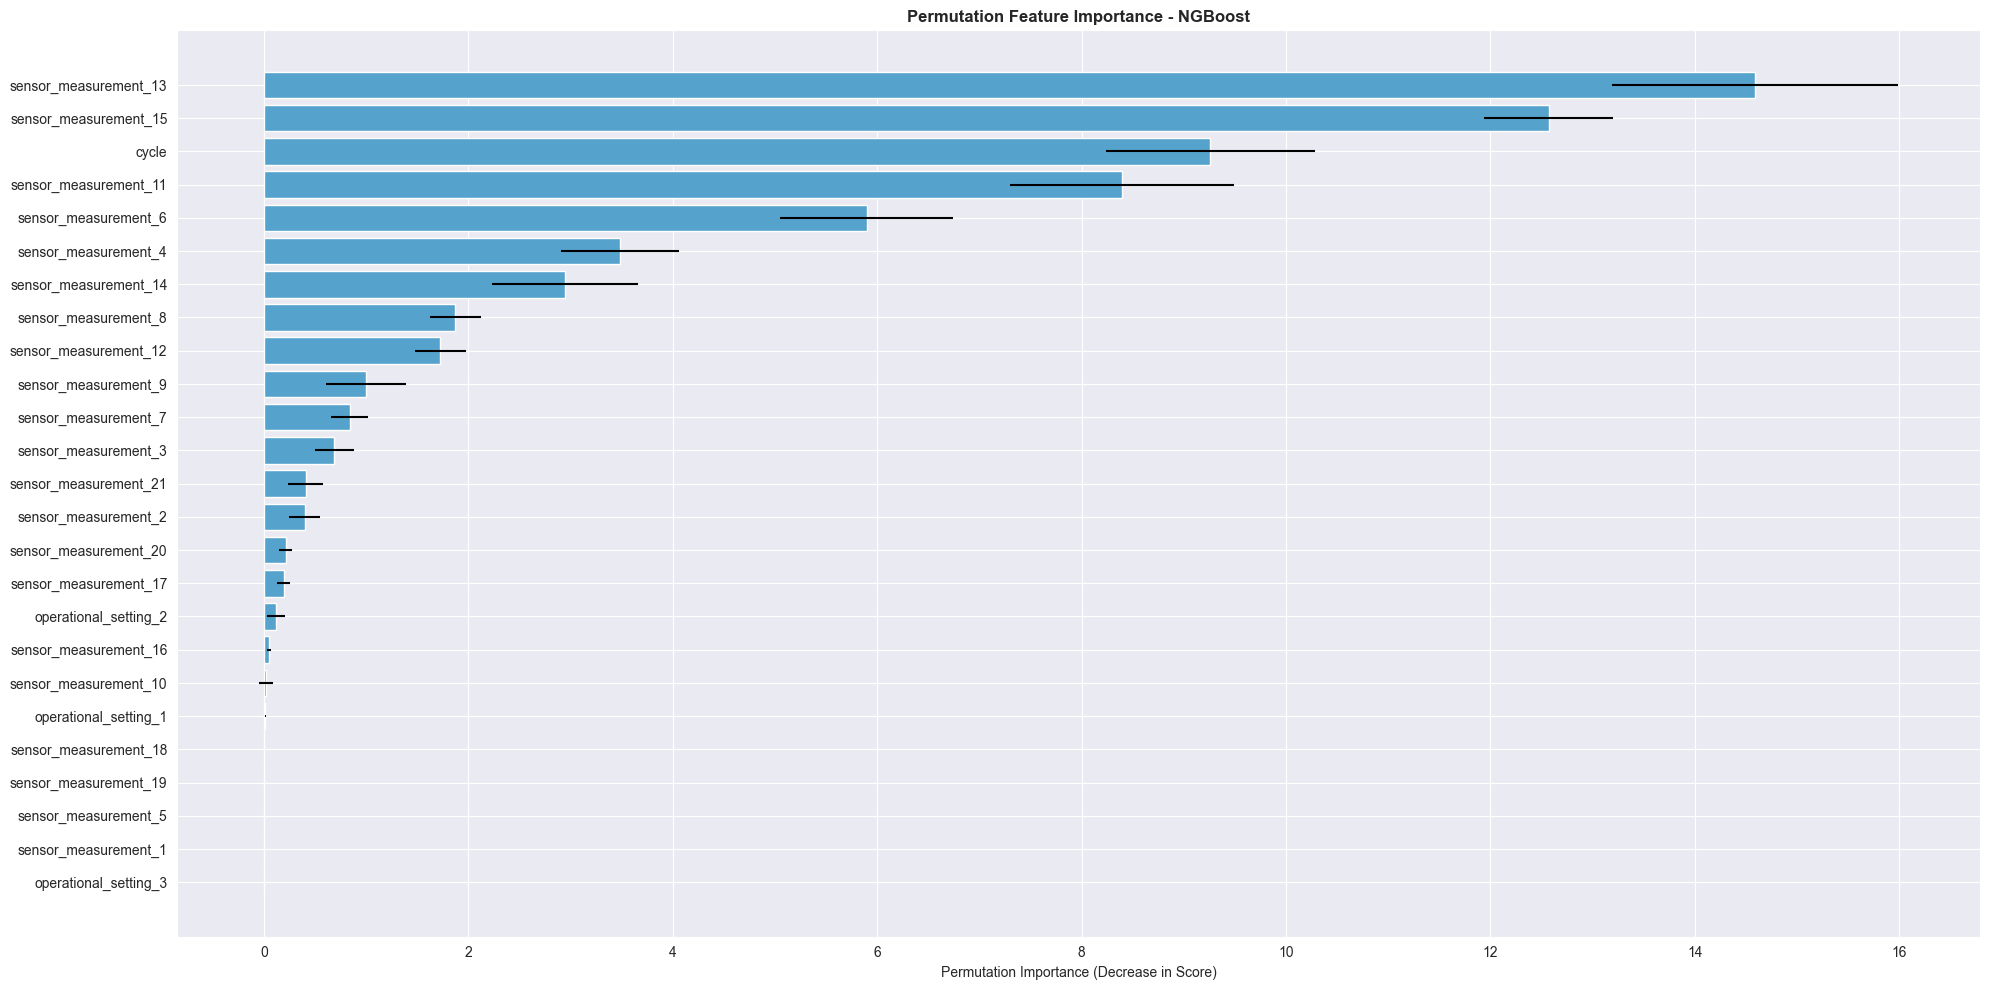

***** MEAN PERFORMANCE *****
R2 MEAN:  0.7658677780827117
MSE MEAN:  556.77874586523


In [ ]:
 # Modelling using ngboost
r2_list_ngboost = []
mse_list_ngboost = []

for (name1, df1), (name2, df2) in zip(train_dfs.items(), test_dfs.items()):
    X_train = df1.iloc[ :,1:-1 ]
    y_train = df1.iloc[ :,-1 ]

    X_test = df2.iloc[ :,1:-1 ]
    y_test = df2.iloc[ :,-1 ]
    
    # Define NGBoost model
    ngb = NGBRegressor(
        Dist=Normal,                     
        Base=DecisionTreeRegressor(max_depth=5),
        natural_gradient=True,
        n_estimators=100,
        learning_rate=0.1,
        verbose=True
    )

     # Train
    ngb.fit(X_train, y_train)
    
    # Get predictive distributions
    y_dists = ngb.pred_dist(X_test)
    means = y_dists.loc
    stds = y_dists.scale

     # Predict mean RUL
    y_pred = ngb.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    r2_list_ngboost.append(r2)
    mse_list_ngboost.append(mse)


    print(f'******{name1} MODEL PEFORMANCE******')
    print(f'Mean Squared Error (MSE): {mse:.2f}')
    print(f'R² Score: {r2:.2f}')

    plt.figure(figsize=(20,6))
    plt.errorbar(y_test, means, yerr=2*stds, fmt='o', alpha=0.5, ecolor='lightgray', capsize=2)

    # Perfect prediction line
    min_val = min(y_test.min(), means.min())
    max_val = max(y_test.max(), means.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

    plt.title('NGBoost RUL Predictions with Uncertainty', fontweight='bold')
    plt.xlabel('True RUL')
    plt.ylabel('Predicted RUL (±2 std)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Get full distribution (mean & std per prediction)
    y_dists = ngb.pred_dist(X_test)
    means = y_dists.loc     # mean predictions
    stds  = y_dists.scale   # uncertainty estimates

     # permutation importance
    result = permutation_importance(
        ngb, X_test, y_test,
        scoring='neg_root_mean_squared_error',  # can also try 'r2'
        n_repeats=10,
        random_state=42
    )

     # Plotting feature importance
    perm_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': result.importances_mean,
        'Std': result.importances_std
    }).sort_values(by='Importance', ascending=True)  # ascending for barh

    # Plot horizontal bar chart
    plt.figure(figsize=(20,10))
    plt.barh(perm_df['Feature'], perm_df['Importance'], xerr=perm_df['Std'])
    plt.xlabel('Permutation Importance (Decrease in Score)')
    plt.title('Permutation Feature Importance - NGBoost', fontweight = 'bold')
    plt.tight_layout()
    plt.show()

print('***** MEAN PERFORMANCE *****')
print('R2 MEAN: ', np.mean(r2_list_ngboost))
print('MSE MEAN: ', np.mean(mse_list_ngboost))
    

From the NGBoost outputs, we observe that **FD001** achieves an MSE of **384.98** and an R² score of **0.78**, representing slightly lower performance compared to XGBoost. The scatter plot closely mirrors that of XGBoost, with points following the diagonal at lower RUL and diverging at higher RUL. The most important predictors are **cycle** and sensor measurements **11, 9, 14, and 4**.

For **FD002**, NGBoost records an MSE of **732.22** and an R² of **0.75**, which is marginally better than XGBoost due to a slightly lower MSE, while maintaining an identical R². The scatter plot shows the same trend observed with XGBoost, where predictions track well at low RUL but underestimate higher values. Key features are **cycle** and sensor measurements **15, 11, 13, and 4**.

For **FD003**, NGBoost achieves an MSE of **352.57** and an R² of **0.79**, which is again a modest improvement over XGBoost, primarily through a reduction in MSE. Scatter plots remain consistent with XGBoost, showing overprediction at higher RUL values. The most influential features are **cycle** and sensor measurements **6, 11, 9, and 14**.

Finally, **FD004** produces an MSE of **766.34** and an R² of **0.74**, which is essentially identical to XGBoost. As before, the scatter plot follows the same pattern, with underprediction in the higher RUL range. The most important predictors are **cycle** and sensor measurements **13, 15, 11, and 6**.

Across all four datasets, the mean metrics for NGBoost are an **MSE of 556** and an **R² of 0.765**, which is slightly below the mean performance of XGBoost (MSE 553.78, R² 0.76).

### **Conclusion**

The results demonstrate that **NGBoost performs comparably to XGBoost**, with near-identical scatter plot behavior and feature importance rankings. While NGBoost offers marginal improvements in certain datasets (FD002 and FD003), its **overall mean performance is slightly lower than XGBoost**. Importantly, both models struggle to extrapolate at higher RUL values, underscoring the challenge of predicting long engine lifespans with tree-based boosting methods.


******FD001 MODEL PEFORMANCE******
Random Forest RMSE: 349.7497435
Random Forest R²: 0.7974660370997323


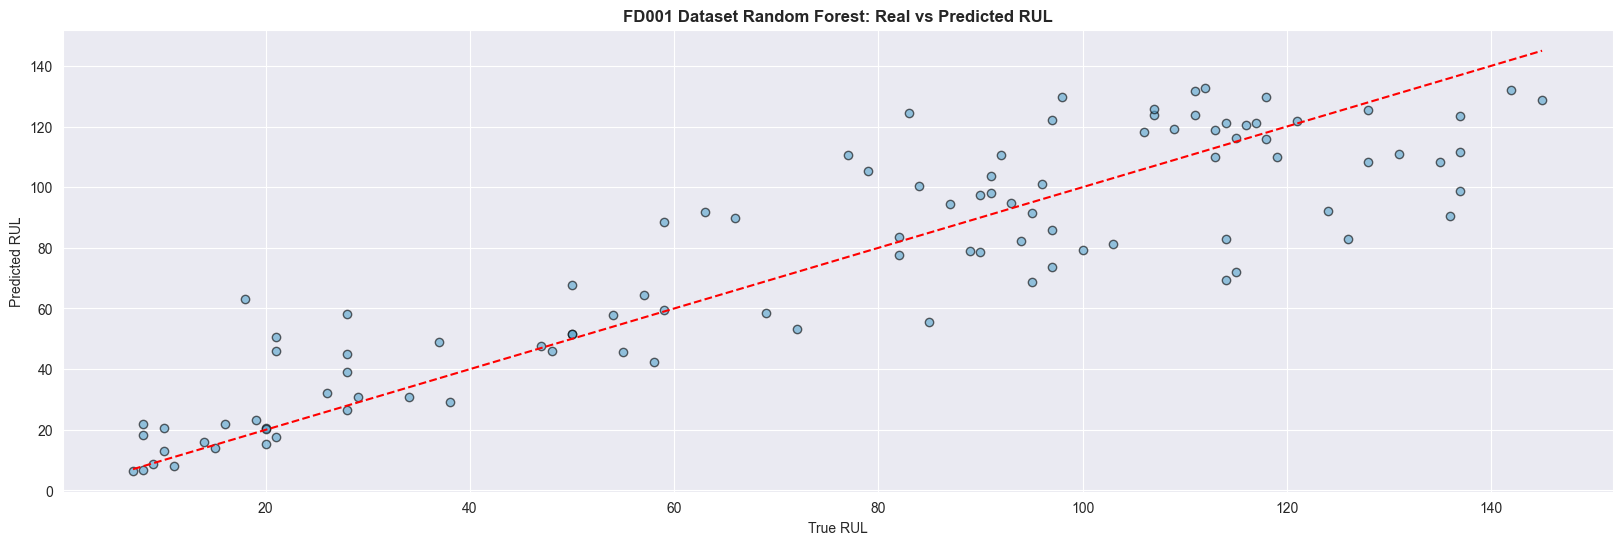

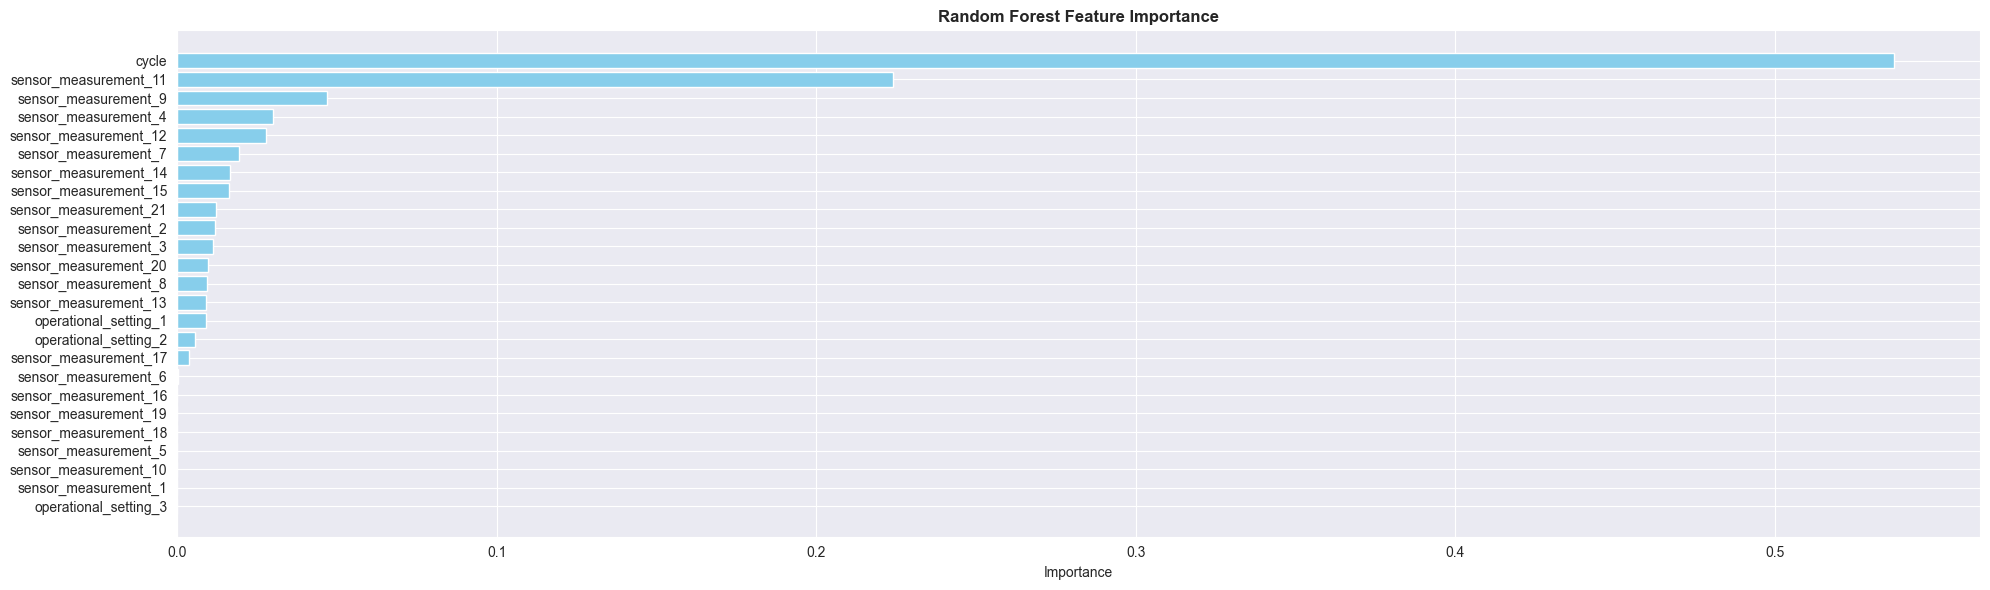

******FD002 MODEL PEFORMANCE******
Random Forest RMSE: 743.3907822393822
Random Forest R²: 0.74296335076652


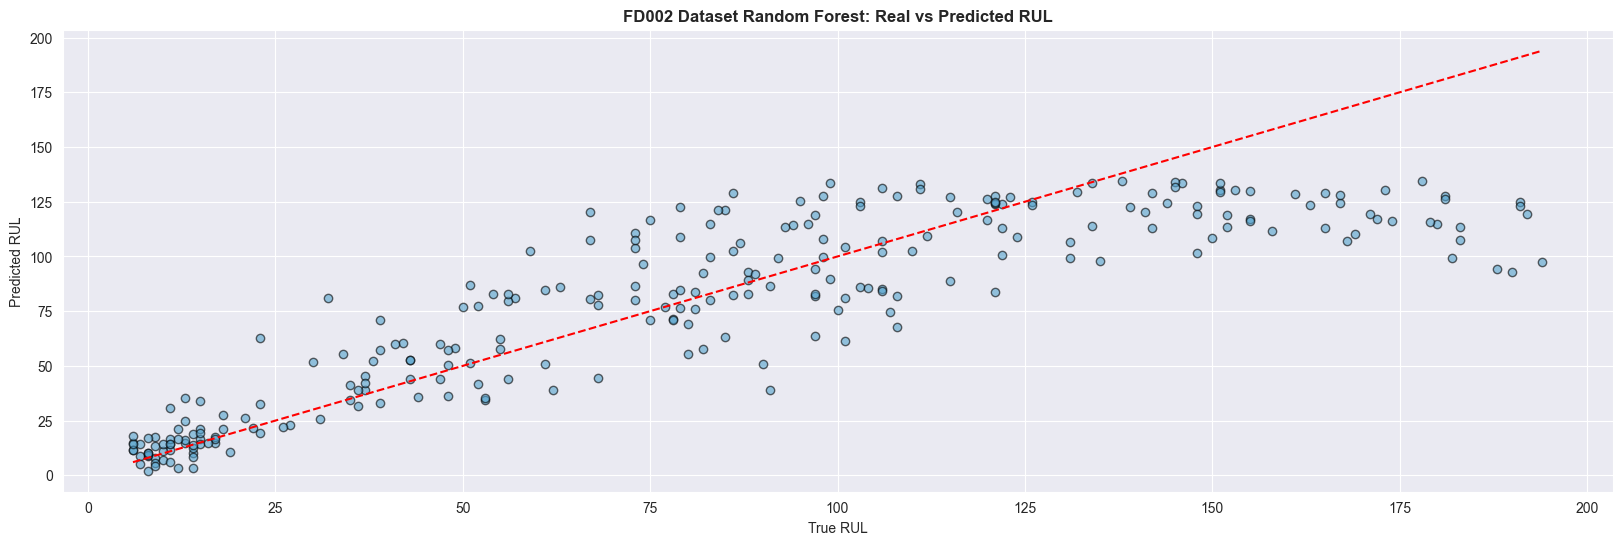

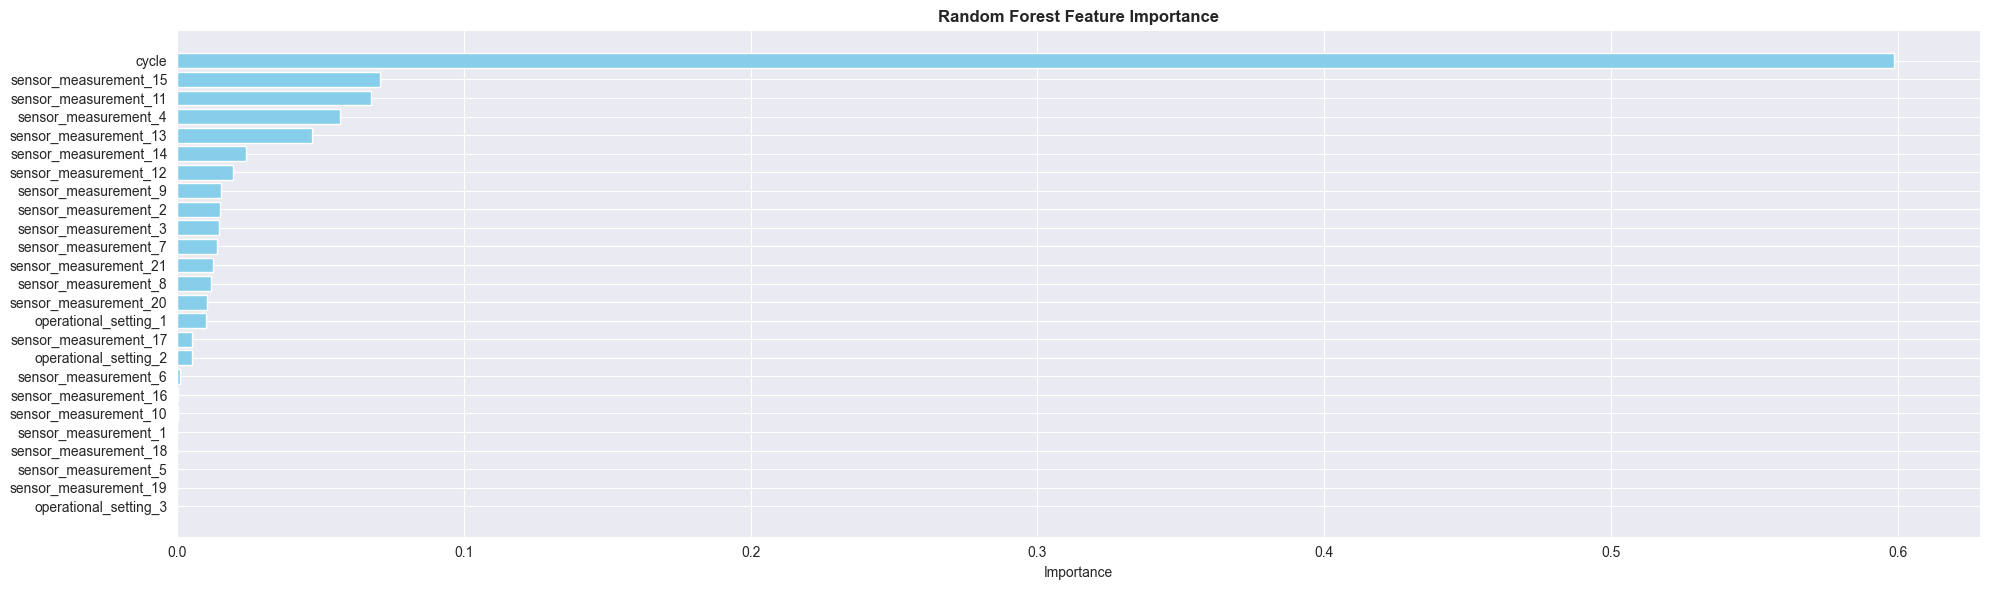

******FD003 MODEL PEFORMANCE******
Random Forest RMSE: 397.75726899999995
Random Forest R²: 0.7678817541527836


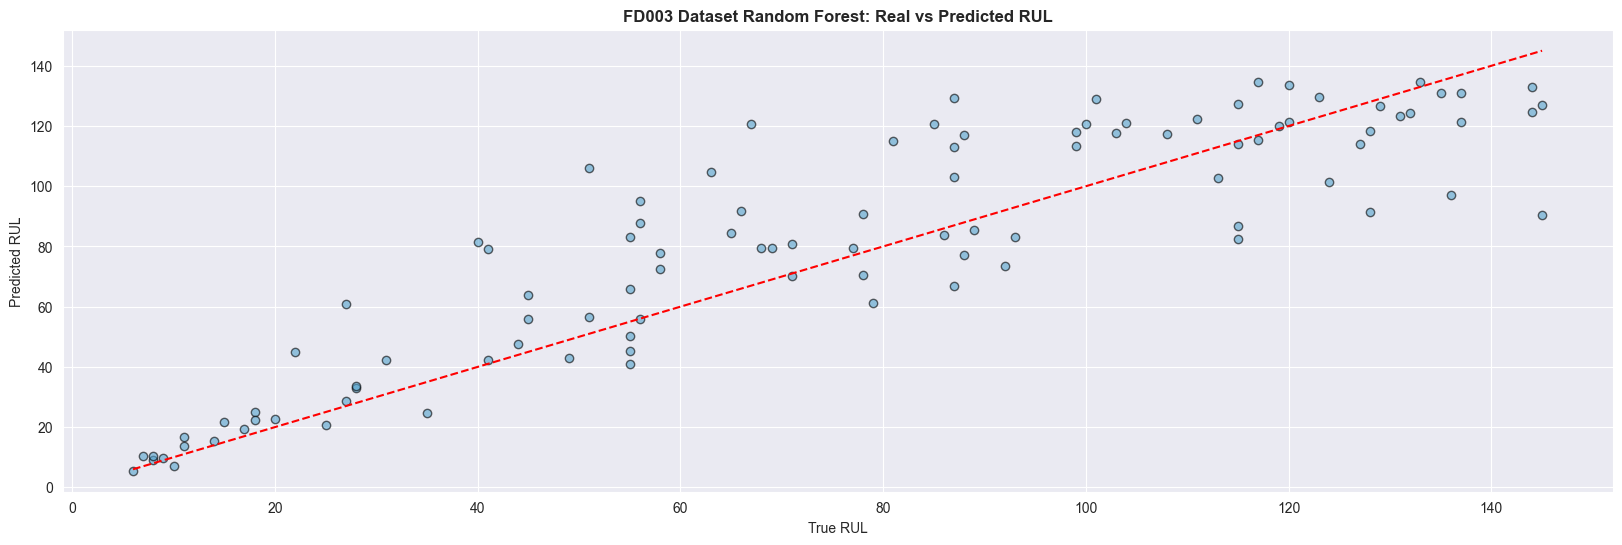

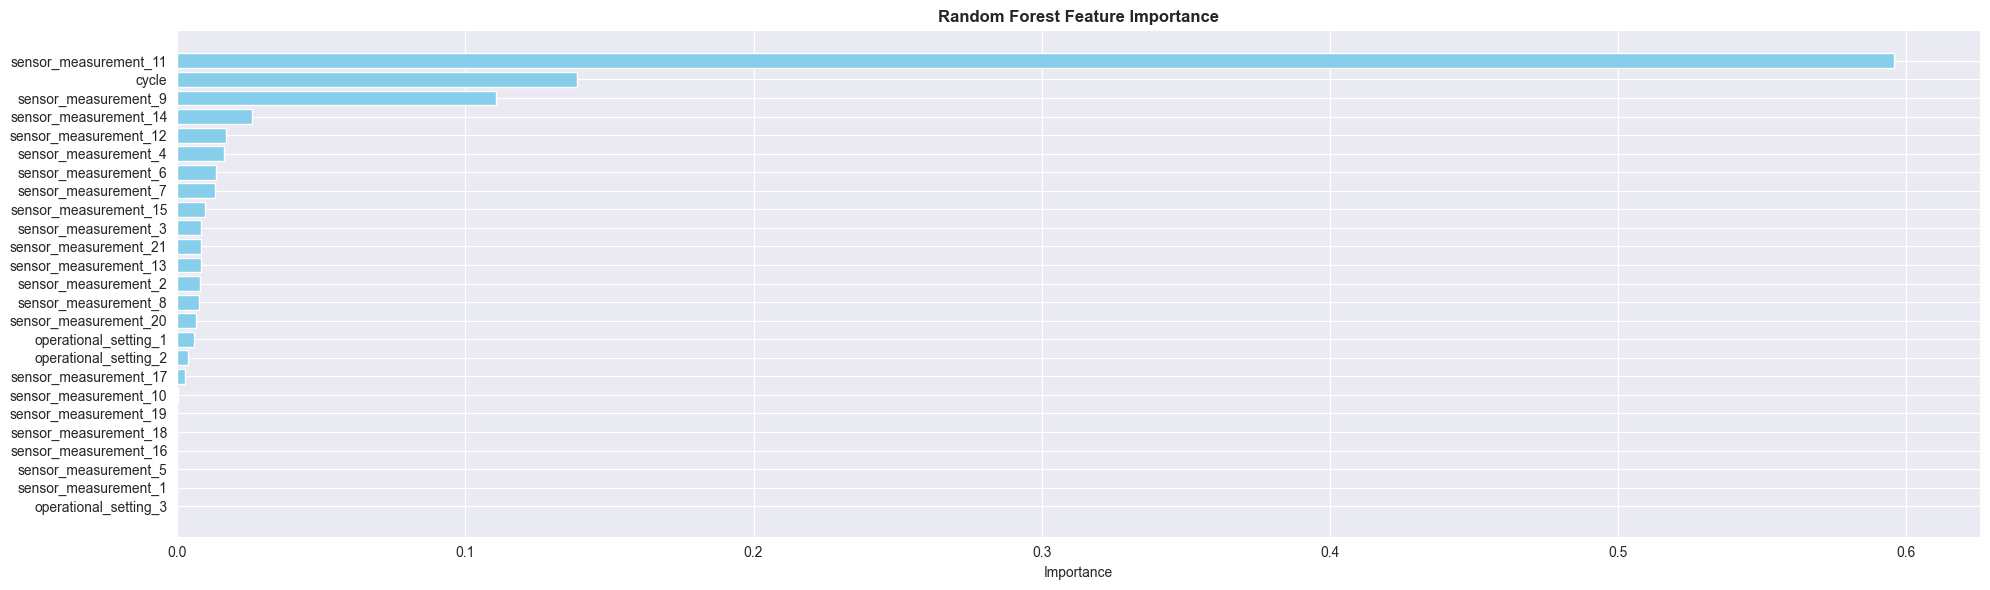

******FD004 MODEL PEFORMANCE******
Random Forest RMSE: 755.8034003024194
Random Forest R²: 0.7457641929447434


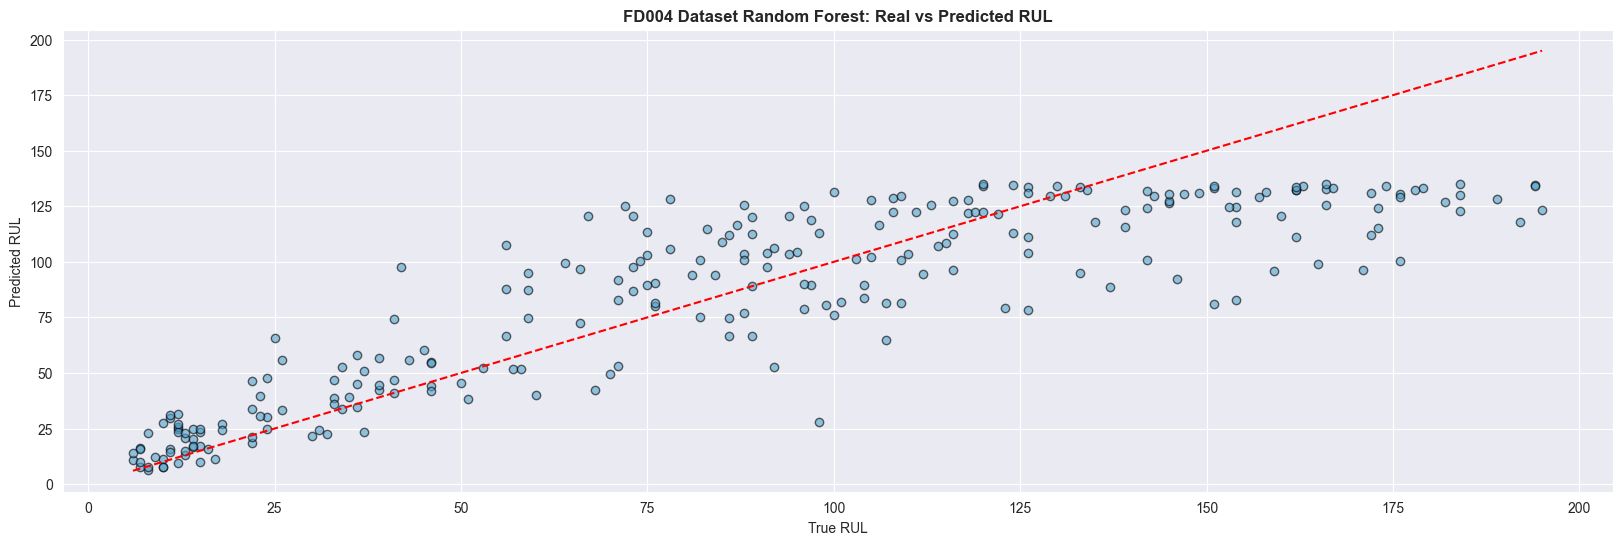

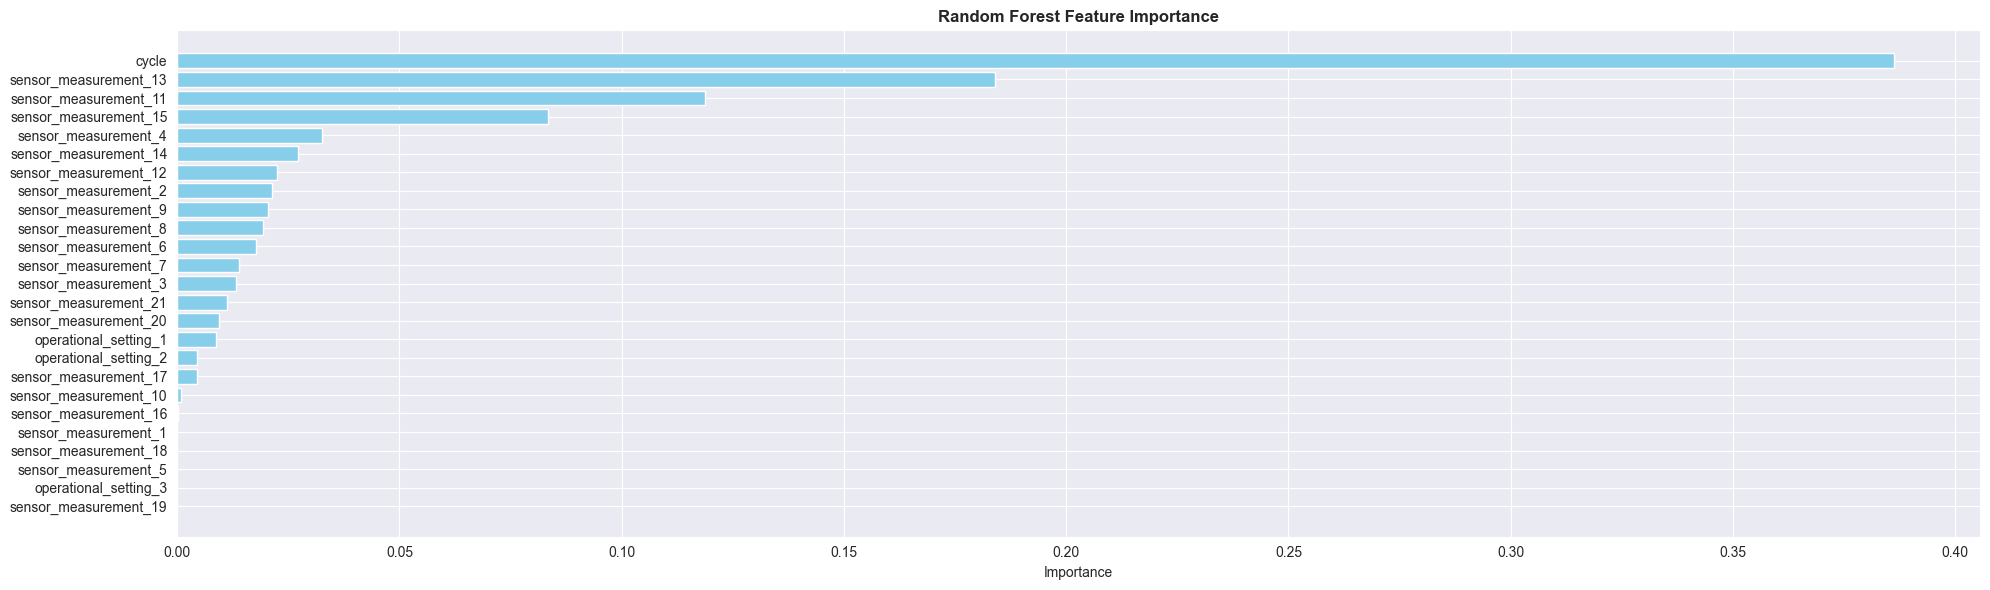

***** MEAN PERFORMANCE *****
R2 MEAN:  0.7635188337409449
MSE MEAN:  561.6752987604503


In [11]:
 # Modelling with Random forest 
r2_list_randomforest = []
mse_list_randomforest = []

for (name1, df1), (name2, df2) in zip(train_dfs.items(), test_dfs.items()):
    X_train = df1.iloc[ :,1:-1 ]
    y_train = df1.iloc[ :,-1 ]

    X_test = df2.iloc[ :,1:-1 ]
    y_test = df2.iloc[ :,-1 ]
    

    # Train Random Forest
    rf = RandomForestRegressor(
        n_estimators=200,     
        max_depth=None,        
        random_state=42,
        n_jobs=-1          
    )
    rf.fit(X_train, y_train)

    # Predict
    y_pred = rf.predict(X_test)

    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test,y_pred)

    r2_list_randomforest.append(r2)
    mse_list_randomforest.append(mse)


    print(f'******{name1} MODEL PEFORMANCE******')

    print('Random Forest RMSE:', mse)
    print('Random Forest R²:', r2)

    # Scatter plot
    plt.figure(figsize=(20,6))
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'{name1} Dataset Random Forest: Real vs Predicted RUL', fontweight = 'bold')
    plt.xlabel('True RUL')
    plt.ylabel('Predicted RUL')
    plt.show()

    importances = rf.feature_importances_
    feat_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=True)

    # barh chart
    plt.figure(figsize=(20,6))
    plt.barh(feat_df['Feature'], feat_df['Importance'], color='skyblue')
    plt.xlabel('Importance')
    plt.title('Random Forest Feature Importance', fontweight = 'bold')
    plt.tight_layout()
    plt.show()

print('***** MEAN PERFORMANCE *****')
print('R2 MEAN: ', np.mean(r2_list_randomforest))
print('MSE MEAN: ', np.mean(mse_list_randomforest))


From the Random Forest model, we observe that the scatter plots are nearly identical to those produced by XGBoost and NGBoost, showing similar prediction trends across all datasets. The performance metrics vary slightly MSE and R² scores are marginally higher or lower depending on the dataset but overall remain comparable to the boosting models. On average, Random Forest achieves a mean R² of 0.7635 and a mean MSE of 561.67, which is slightly worse than both XGBoost and NGBoost (higher MSE, marginally lower R²). Consistent with the other models, Random Forest also struggles to extrapolate to higher RUL values, highlighting the inherent difficulty of capturing long term degradation patterns with tree-based methods.

## **CONCLUSIONS**
Comparing the results across all models, it is evident that **XGBoost consistently outperforms** the alternatives with the best overall balance of accuracy and error, achieving a mean R² of 0.76 and a mean MSE of 553.78 across all datasets. NGBoost delivers nearly identical results, showing marginal improvements in certain datasets (FD002 and FD003) but slightly lower mean performance overall. Random Forest produces comparable outcomes as well, though with a slightly higher mean MSE of 561.67 and a mean R² of 0.7635, placing it just below the boosting methods. Linear and Ridge regression, by contrast, significantly underperform due to their inability to capture nonlinear degradation patterns. Across all models, the scatter plots confirm that predicting extreme RUL values remains a challenge, with systematic underprediction or overprediction at higher cycles.

Based on these findings, **we select XGBoost as the preferred model, given its superior performance metrics and stability across datasets**. Moreover, feature importance analysis consistently highlights cycle and sensor measurement 11 as critical predictors of Remaining Useful Life. We will therefore move forward with optimizing the XGBoost model, refining its parameters to maximize predictive performance.
